# PCOS — Preprocessing Pipeline

**Input:** `pcos_dataset.csv` (1,000 patients × 5 predictors + 1 binary target)
**Output:** cleaned data, four model-ready feature spaces, and a fitted, reusable
`sklearn` pipeline saved to disk.

This notebook is the bridge between `eda.ipynb` and modelling. Everything it does is a
*consequence* of a finding in the EDA rather than a habit applied by default — the reasoning
for each decision is stated where the decision is made.

---

### What the EDA established, and what it implies for preprocessing

| EDA finding | Preprocessing consequence |
|---|---|
| 0 missing, 0 duplicates, 0 implausible values | Nothing to repair **today** — but the cleaner is still built and tested, because the next export of this data will not be so lucky |
| No outliers under IQR, z-score or Mahalanobis | **No** winsorising, **no** robust scaling, **no** log transforms |
| All four numeric features uniform, mutually independent (max \|r\| = 0.05) | **No** PCA, **no** decorrelation, **no** normality transforms — every one would destroy signal and buy nothing |
| Label = deterministic conjunction of 4 axis-parallel thresholds | **Threshold indicator features are the single highest-value transformation available** |
| 19.9 % positive (≈ 4 : 1) | Stratify every split; compute class weights; test — don't assume — whether resampling helps |
| `Age` contributes nothing under 4 independent importance methods | Keep it, but ship a feature space without it so the claim stays testable |
| Feature name `Testosterone_Level(ng/dL)` | Rename — XGBoost and LightGBM reject `(`, `)` and `/` in feature names |

### The one thing the EDA did not do

`eda.ipynb` discovered the cut-points (BMI 25, testosterone 40, AFC 10) by fitting a tree to
**all 1,000 rows** — test set included — and then hard-coded them. That is fine for
*understanding* the data and wrong for *reporting a score*: the engineered features would carry
information from the rows they are later evaluated on.

This notebook fixes that. Cut-points are re-discovered by a supervised transformer that only ever
sees the training fold, so every number below survives scrutiny.

---

### Contents

| # | Section | What it produces |
|---|---|---|
| 0 | Setup | Config, paths, plotting theme |
| 1 | Load & schema contract | Raw frame + an explicit contract to validate against |
| 2 | Data-quality audit | Evidence for every cleaning decision |
| 3 | The preprocessing toolkit | Cleaner, threshold encoder, pipeline builder - all in-notebook |
| 4 | Cleaning | Cleaned frame + an action log, proven on deliberately corrupted data |
| 5 | Leakage-safe split | Stratified train / test, made *before* anything is fitted |
| 6 | Threshold discovery | Cut-points learned from the training fold only |
| 7 | Feature engineering | Indicators, criteria count, composite flag + a redundancy audit |
| 8 | Scaling & the five feature spaces | `raw` · `scaled` · `engineered` · `lean` · `count` |
| 9 | Class imbalance | Weights, resampling — and evidence on whether to use them |
| 10 | Validation | Leakage assertions + a CV benchmark across all five spaces |
| 11 | Persist | `.joblib` pipelines, processed CSVs, metadata |
| 12 | How to use it | The three lines a modelling notebook needs |

---
## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import sys
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.set_printoptions(suppress=True)

# ---- configuration ---------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_FOLDS      = 5

CSV_PATH  = Path("pcos_dataset.csv")
DATA_DIR  = Path("data/processed")
ART_DIR   = Path("artifacts")
for d in (DATA_DIR, ART_DIR):
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("joblib      ", joblib.__version__)
print(f"\noutputs -> {DATA_DIR}/  and  {ART_DIR}/")

python       3.14.3
numpy        2.4.2
pandas       3.0.1
scikit-learn 1.9.0
joblib       1.5.3

outputs -> data\processed/  and  artifacts/


In [2]:
# ---- Plotting system -------------------------------------------------------
# Same palette as eda.ipynb so the two notebooks read as one document.
# Categorical slots are assigned in fixed order and never cycled.
CAT = {
    "blue":   "#2a78d6",   # slot 1
    "orange": "#eb6834",   # slot 2
    "aqua":   "#1baf7a",   # slot 3
    "yellow": "#eda100",   # slot 4
    "violet": "#4a3aa7",   # slot 5
}
CAT_ORDER = list(CAT.values())

NEG, POS   = CAT["blue"], CAT["orange"]        # 0 = No PCOS, 1 = PCOS, held constant
CLASS_COLOR = {0: NEG, 1: POS}
CLASS_NAME  = {0: "No PCOS", 1: "PCOS"}

SURFACE, INK, INK2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
)

sns.set_theme(style="whitegrid")
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10.5,
    "axes.titlesize": 12.5, "axes.titleweight": "600", "axes.titlepad": 12,
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.labelsize": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK2,
    "figure.dpi": 110, "figure.autolayout": False,
    "axes.prop_cycle": mpl.cycler(color=CAT_ORDER),
})


def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    # House style for one axes: recessive grid, quiet chrome, subtitle under the title.
    if title:
        ax.set_title(title, loc="left", pad=27 if sub else 12)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.5,
                color=MUTED, ha="left", va="bottom")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", visible=ygrid)
    ax.grid(axis="x", visible=xgrid)
    return ax


def show(fig, pad=1.6):
    fig.tight_layout(pad=pad)
    plt.show()


def section(title):
    bar = "=" * max(len(title) + 4, 62)
    print(f"\n{bar}\n  {title}\n{bar}")


def verdict(passed, ok="PASS", bad="FAIL"):
    return ok if passed else bad

---
## 1 · Load the raw file & state the schema contract

A *contract* is written down before the data is inspected: the columns that must exist, their
role, and the range each is physically allowed to occupy. Everything after this point validates
against the contract instead of against whatever happens to be in today's file — which is what
makes the audit re-runnable on the next export.

In [3]:
raw = pd.read_csv(CSV_PATH)

section("RAW FILE AS DELIVERED")
print(f"Path      : {CSV_PATH.resolve()}")
print(f"Rows      : {raw.shape[0]:,}")
print(f"Columns   : {raw.shape[1]}")
print(f"Memory    : {raw.memory_usage(deep=True).sum() / 1024:,.1f} KB")
raw.head()


  RAW FILE AS DELIVERED
Path      : C:\Users\Adri\Downloads\pcos\pcos_dataset.csv
Rows      : 1,000
Columns   : 6
Memory    : 47.0 KB


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7000,1,25.2000,20,0
1,37,26.4000,0,57.1000,25,0
2,32,23.6000,0,92.7000,28,0
3,28,28.8000,0,63.1000,26,0
4,25,22.1000,1,59.8000,8,0


In [4]:
# The contract. `bounds` are physiological hard limits - a value outside them is an ERROR,
# not an outlier. They are deliberately far wider than the observed spread, so the check
# catches data-entry faults without ever trimming a legitimate patient.
CONTRACT = {
    "Age":                       dict(role="feature",  kind="continuous", bounds=(10, 70),
                                      unit="years",  note="reproductive-age window"),
    "BMI":                       dict(role="feature",  kind="continuous", bounds=(10, 80),
                                      unit="kg/m^2", note="survivable BMI range"),
    "Menstrual_Irregularity":    dict(role="feature",  kind="binary",     bounds=(0, 1),
                                      unit="0/1",    note="0 = regular, 1 = irregular"),
    "Testosterone_Level(ng/dL)": dict(role="feature",  kind="continuous", bounds=(1, 400),
                                      unit="ng/dL",  note="total testosterone, female"),
    "Antral_Follicle_Count":     dict(role="feature",  kind="count",      bounds=(0, 80),
                                      unit="count",  note="both ovaries"),
    "PCOS_Diagnosis":            dict(role="TARGET",   kind="binary",     bounds=(0, 1),
                                      unit="0/1",    note="0 = no PCOS, 1 = PCOS"),
}

section("SCHEMA CONTRACT vs. DELIVERED FILE")
rows = []
for col, spec in CONTRACT.items():
    present = col in raw.columns
    s = raw[col] if present else pd.Series(dtype=float)
    rows.append({
        "column": col,
        "role": spec["role"],
        "kind": spec["kind"],
        "unit": spec["unit"],
        "present": verdict(present, "yes", "MISSING"),
        "dtype": str(s.dtype) if present else "-",
        "n_unique": int(s.nunique()) if present else 0,
        "observed_min": s.min() if present and len(s) else np.nan,
        "observed_max": s.max() if present and len(s) else np.nan,
        "allowed": f"[{spec['bounds'][0]}, {spec['bounds'][1]}]",
    })
contract_tbl = pd.DataFrame(rows).set_index("column")
display(contract_tbl)

unexpected = [c for c in raw.columns if c not in CONTRACT]
print(f"Columns in the contract but absent from the file : "
      f"{[c for c in CONTRACT if c not in raw.columns] or 'none'}")
print(f"Columns in the file but absent from the contract : {unexpected or 'none'}")


  SCHEMA CONTRACT vs. DELIVERED FILE


,role,kind,unit,present,dtype,n_unique,observed_min,observed_max,allowed
column,,,,,,,,,
Age,feature,continuous,years,yes,int64,28,18.0000,45.0000,"[10, 70]"
BMI,feature,continuous,kg/m^2,yes,float64,170,18.1000,35.0000,"[10, 80]"
Menstrual_Irregularity,feature,binary,0/1,yes,int64,2,0.0000,1.0000,"[0, 1]"
Testosterone_Level(ng/dL),feature,continuous,ng/dL,yes,float64,577,20.0000,99.8000,"[1, 400]"
Antral_Follicle_Count,feature,count,count,yes,int64,25,5.0000,29.0000,"[0, 80]"
PCOS_Diagnosis,TARGET,binary,0/1,yes,int64,2,0.0000,1.0000,"[0, 1]"


Columns in the contract but absent from the file : none
Columns in the file but absent from the contract : none


---
## 2 · Data-quality audit

Seven checks. Each one either authorises a cleaning step or rules it out — nothing is applied
because it is customary.

In [5]:
section("2.1  MISSINGNESS, INCLUDING DISGUISED MISSINGNESS")

miss = pd.DataFrame({
    "n_missing": raw.isna().sum(),
    "pct_missing": (raw.isna().mean() * 100).round(3),
})
print(miss.to_string())
print(f"\nTotal missing cells       : {int(raw.isna().sum().sum())}")
print(f"Rows with >= 1 missing    : {int(raw.isna().any(axis=1).sum())}")

# A NaN is the easy case. The dangerous case is a real number standing in for "unknown":
# a -999 code, an empty-string-turned-zero, or a placeholder like 9999.
SENTINELS = [-999, -99, -9, -1, 999, 9999]
print("\nDisguised-missing sweep (sentinel codes and suspicious zeros):")
for c in raw.columns:
    s = pd.to_numeric(raw[c], errors="coerce")
    n_sent = int(s.isin(SENTINELS).sum())
    n_zero = int((s == 0).sum())
    legit_zero = CONTRACT[c]["kind"] in ("binary", "count")
    zero_note = "" if legit_zero else ("  <-- zero is NOT a valid value here" if n_zero else "")
    print(f"  {c:28s} sentinel-coded={n_sent:4d}   zeros={n_zero:4d}{zero_note}")

print("\n-> No NaN, no sentinel codes. The only zeros are legitimate: 470 regular-cycle")
print("   patients and 801 negative diagnoses, both genuine 0-values of a binary column.")


  2.1  MISSINGNESS, INCLUDING DISGUISED MISSINGNESS
                           n_missing  pct_missing
Age                                0       0.0000
BMI                                0       0.0000
Menstrual_Irregularity             0       0.0000
Testosterone_Level(ng/dL)          0       0.0000
Antral_Follicle_Count              0       0.0000
PCOS_Diagnosis                     0       0.0000

Total missing cells       : 0
Rows with >= 1 missing    : 0

Disguised-missing sweep (sentinel codes and suspicious zeros):
  Age                          sentinel-coded=   0   zeros=   0
  BMI                          sentinel-coded=   0   zeros=   0
  Menstrual_Irregularity       sentinel-coded=   0   zeros= 470
  Testosterone_Level(ng/dL)    sentinel-coded=   0   zeros=   0
  Antral_Follicle_Count        sentinel-coded=   0   zeros=   0
  PCOS_Diagnosis               sentinel-coded=   0   zeros= 801

-> No NaN, no sentinel codes. The only zeros are legitimate: 470 regular-cycle
   patie

In [6]:
section("2.2  DUPLICATES AND LABEL CONTRADICTIONS")

feat_cols = [c for c in CONTRACT if CONTRACT[c]["role"] == "feature"]
target_col = "PCOS_Diagnosis"

n_exact = int(raw.duplicated().sum())
n_feat  = int(raw.duplicated(subset=feat_cols).sum())
print(f"Rows identical on features AND label : {n_exact}")
print(f"Rows identical on features only      : {n_feat}")

if n_feat:
    grp = raw.groupby(feat_cols)[target_col].nunique()
    print(f"  ...of which carry CONTRADICTORY labels: {int((grp > 1).sum())}")
else:
    print("  -> every row is a unique feature vector, so there is nothing to de-duplicate")
    print("     and no contradictory label to arbitrate.")

print("\nWhy this matters: a duplicated row that lands on both sides of the train/test split")
print("leaks the answer and inflates the test score. Zero duplicates means the hold-out")
print("number later in this notebook is measuring generalisation, not recall of a seen row.")


  2.2  DUPLICATES AND LABEL CONTRADICTIONS
Rows identical on features AND label : 0
Rows identical on features only      : 0
  -> every row is a unique feature vector, so there is nothing to de-duplicate
     and no contradictory label to arbitrate.

Why this matters: a duplicated row that lands on both sides of the train/test split
leaks the answer and inflates the test score. Zero duplicates means the hold-out
number later in this notebook is measuring generalisation, not recall of a seen row.


In [7]:
section("2.3  VALUE PLAUSIBILITY vs. THE CONTRACT")

rows, all_ok = [], True
for col, spec in CONTRACT.items():
    s = pd.to_numeric(raw[col], errors="coerce")
    lo, hi = spec["bounds"]
    n_low  = int((s < lo).sum())
    n_high = int((s > hi).sum())
    n_nan  = int(s.isna().sum() - raw[col].isna().sum())      # became NaN only by coercion
    n_bad_binary = (int((~s.isin([0, 1]) & s.notna()).sum())
                    if spec["kind"] == "binary" else 0)
    n_non_int = (int((s.dropna() % 1 != 0).sum())
                 if spec["kind"] in ("count", "binary") else 0)
    ok = (n_low + n_high + n_nan + n_bad_binary + n_non_int) == 0
    all_ok &= ok
    rows.append({
        "column": col, "below_min": n_low, "above_max": n_high,
        "unparseable": n_nan, "not_in_{0,1}": n_bad_binary,
        "non_integer": n_non_int, "result": verdict(ok),
    })
display(pd.DataFrame(rows).set_index("column"))
print(f"-> {'ALL VALUES INSIDE CONTRACT' if all_ok else 'CONTRACT VIOLATIONS PRESENT'}")


  2.3  VALUE PLAUSIBILITY vs. THE CONTRACT


,below_min,above_max,unparseable,"not_in_{0,1}",non_integer,result
column,,,,,,
Age,0,0,0,0,0,PASS
BMI,0,0,0,0,0,PASS
Menstrual_Irregularity,0,0,0,0,0,PASS
Testosterone_Level(ng/dL),0,0,0,0,0,PASS
Antral_Follicle_Count,0,0,0,0,0,PASS
PCOS_Diagnosis,0,0,0,0,0,PASS


-> ALL VALUES INSIDE CONTRACT


In [8]:
section("2.4  DISTRIBUTION SHAPE - does anything need a transform?")

numeric = [c for c, s in CONTRACT.items() if s["kind"] in ("continuous", "count")]
shape = pd.DataFrame({
    "skew": raw[numeric].skew(),
    "kurtosis": raw[numeric].kurtosis(),
    "min": raw[numeric].min(),
    "max": raw[numeric].max(),
})
shape["needs_log"]      = np.where(shape["skew"].abs() > 1.0, "YES", "no")
shape["heavy_tailed"]   = np.where(shape["kurtosis"] > 3.0, "YES", "no")
shape["scale_span"]     = shape["max"] / shape["min"].replace(0, np.nan)
display(shape.round(4))

span = raw[numeric].max() / raw[numeric].min()
print(f"Widest single-feature dynamic range : {span.max():.1f}x  ({span.idxmax()})")
print(f"Ratio between the largest and smallest feature std: "
      f"{raw[numeric].std().max() / raw[numeric].std().min():.1f}x")
print()
print("-> Every |skew| < 0.1 and every kurtosis ~ -1.2 (flat-topped, thin-tailed).")
print("   No log, sqrt, Box-Cox or Yeo-Johnson transform is warranted: they exist to pull in")
print("   a long right tail, and there is no tail here to pull in.")
print("-> But the FEATURE SCALES differ by ~5x in standard deviation. That is irrelevant to a")
print("   tree and decisive for KNN, SVM and the MLP, so STANDARDISATION is required - for")
print("   those models only. Section 8 builds both a scaled and an unscaled space.")


  2.4  DISTRIBUTION SHAPE - does anything need a transform?


,skew,kurtosis,min,max,needs_log,heavy_tailed,scale_span
Age,-0.0604,-1.2739,18.0000,45.0000,no,no,2.5000
BMI,0.0238,-1.2311,18.1000,35.0000,no,no,1.9337
Testosterone_Level(ng/dL),-0.0193,-1.1823,20.0000,99.8000,no,no,4.9900
Antral_Follicle_Count,-0.0764,-1.1543,5.0000,29.0000,no,no,5.8000


Widest single-feature dynamic range : 5.8x  (Antral_Follicle_Count)


Ratio between the largest and smallest feature std: 4.7x

-> Every |skew| < 0.1 and every kurtosis ~ -1.2 (flat-topped, thin-tailed).
   No log, sqrt, Box-Cox or Yeo-Johnson transform is warranted: they exist to pull in
   a long right tail, and there is no tail here to pull in.
-> But the FEATURE SCALES differ by ~5x in standard deviation. That is irrelevant to a
   tree and decisive for KNN, SVM and the MLP, so STANDARDISATION is required - for
   those models only. Section 8 builds both a scaled and an unscaled space.


In [9]:
section("2.5  TARGET INTEGRITY & CLASS BALANCE")

counts = raw[target_col].value_counts().sort_index()
pcts   = raw[target_col].value_counts(normalize=True).sort_index() * 100
ratio  = counts[0] / counts[1]

print(f"  0  {CLASS_NAME[0]:8s} : {counts[0]:4d}  ({pcts[0]:5.2f}%)")
print(f"  1  {CLASS_NAME[1]:8s} : {counts[1]:4d}  ({pcts[1]:5.2f}%)")
print(f"\nImbalance ratio      : {ratio:.2f} : 1")
print(f"Majority baseline    : {pcts[0]:.2f}% accuracy for a model that always says 'No PCOS'")
print(f"Smallest class size  : {counts.min()} - comfortably above the ~50 needed for {N_FOLDS}-fold CV")
print(f"Positives per fold   : ~{counts[1] / N_FOLDS:.0f}")
print()
print("-> Moderate imbalance. Consequences, all applied later:")
print("   * every split is STRATIFIED (section 5), or a fold could drift several points off 19.9%")
print("   * accuracy is reported alongside F1 / recall, never alone")
print("   * class weights are computed (section 9) so a model can use them if it wants")


  2.5  TARGET INTEGRITY & CLASS BALANCE
  0  No PCOS  :  801  (80.10%)
  1  PCOS     :  199  (19.90%)

Imbalance ratio      : 4.03 : 1
Majority baseline    : 80.10% accuracy for a model that always says 'No PCOS'
Smallest class size  : 199 - comfortably above the ~50 needed for 5-fold CV
Positives per fold   : ~40

-> Moderate imbalance. Consequences, all applied later:
   * every split is STRATIFIED (section 5), or a fold could drift several points off 19.9%
   * accuracy is reported alongside F1 / recall, never alone
   * class weights are computed (section 9) so a model can use them if it wants


In [10]:
section("2.6  FEATURE REDUNDANCY - is any column derivable from the others?")

X_num = raw[feat_cols].astype(float)
corr = X_num.corr()
off = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Strongest feature-to-feature correlations:")
print(off.reindex(off.abs().sort_values(ascending=False).index).head(4).round(4).to_string())
print(f"\nLargest |r| between any two features : {off.abs().max():.4f}")

from sklearn.linear_model import LinearRegression
vif = {}
for i, name in enumerate(feat_cols):
    others = [c for c in feat_cols if c != name]
    r2 = LinearRegression().fit(X_num[others], X_num[name]).score(X_num[others], X_num[name])
    vif[name] = 1 / max(1 - r2, 1e-12)
print("\nVariance inflation factors:")
print(pd.Series(vif, name="VIF").round(4).to_string())
print("\n-> Every VIF ~ 1.00 and max |r| = 0.05. No column is redundant, so there is nothing to")
print("   drop for collinearity and NO REASON TO RUN PCA: the five features are already an")
print("   orthogonal basis, and projecting them would mix independent signals into worse ones.")


  2.6  FEATURE REDUNDANCY - is any column derivable from the others?
Strongest feature-to-feature correlations:
Age                     Testosterone_Level(ng/dL)   -0.0501
                        BMI                         -0.0495
Menstrual_Irregularity  Testosterone_Level(ng/dL)    0.0427
                        Antral_Follicle_Count        0.0359

Largest |r| between any two features : 0.0501



Variance inflation factors:
Age                         1.0066
BMI                         1.0045
Menstrual_Irregularity      1.0052
Testosterone_Level(ng/dL)   1.0046
Antral_Follicle_Count       1.0026

-> Every VIF ~ 1.00 and max |r| = 0.05. No column is redundant, so there is nothing to
   drop for collinearity and NO REASON TO RUN PCA: the five features are already an
   orthogonal basis, and projecting them would mix independent signals into worse ones.


In [11]:
section("2.7  AUDIT SCORECARD")

checks = [
    ("Every contracted column present",
     all(c in raw.columns for c in CONTRACT)),
    ("No unexpected extra columns",
     len(unexpected) == 0),
    ("No missing values",
     int(raw.isna().sum().sum()) == 0),
    ("No disguised-missing sentinel codes",
     not any(pd.to_numeric(raw[c], errors="coerce").isin(SENTINELS).any() for c in raw.columns)),
    ("No exact duplicate rows",
     n_exact == 0),
    ("No contradictory labels",
     n_feat == 0),
    ("All values inside contract bounds",
     all_ok),
    ("All columns numeric",
     all(pd.api.types.is_numeric_dtype(raw[c]) for c in raw.columns)),
    ("Target strictly binary",
     set(pd.unique(raw[target_col])) == {0, 1}),
    ("No constant / quasi-constant feature",
     all(raw[c].value_counts(normalize=True).iloc[0] < 0.95 for c in feat_cols)),
    ("No skew needing a transform",
     bool((raw[numeric].skew().abs() < 1.0).all())),
    ("No multicollinearity (VIF < 5)",
     max(vif.values()) < 5),
    ("Minority class >= 50 rows",
     int(counts.min()) >= 50),
]
score = pd.DataFrame(checks, columns=["check", "passed"])
score["result"] = score["passed"].map(lambda b: verdict(b))
print(score[["check", "result"]].to_string(index=False))
print(f"\nScore: {int(score['passed'].sum())}/{len(score)} checks passed")


  2.7  AUDIT SCORECARD
                               check result
     Every contracted column present   PASS
         No unexpected extra columns   PASS
                   No missing values   PASS
 No disguised-missing sentinel codes   PASS
             No exact duplicate rows   PASS
             No contradictory labels   PASS
   All values inside contract bounds   PASS
                 All columns numeric   PASS
              Target strictly binary   PASS
No constant / quasi-constant feature   PASS
         No skew needing a transform   PASS
      No multicollinearity (VIF < 5)   PASS
           Minority class >= 50 rows   PASS

Score: 13/13 checks passed


### Reading the audit — what preprocessing this data actually needs

**Ruled out, with evidence:** imputation (nothing missing) · de-duplication (nothing duplicated) ·
outlier removal or winsorising (no outliers under any of three detectors) · log / Box-Cox /
Yeo-Johnson (|skew| < 0.1) · PCA or decorrelation (VIF ≈ 1) · robust scaling (no tails to be
robust to) · one-hot encoding (no categoricals).

Applying any of those here would be cargo-cult preprocessing: motion that costs signal and buys
nothing.

**Genuinely required, and worth doing well:**

1. **Rename** `Testosterone_Level(ng/dL)` → `Testosterone`. Cosmetic here, mandatory the moment
   XGBoost or LightGBM is used — both reject `(`, `)` and `/` in feature names.
2. **Standardise the continuous columns**, but for *distance- and gradient-based models only*.
   The feature standard deviations differ by ~5×, which KNN, SVM-RBF and the MLP all feel and
   trees do not. Section 10 measures the effect: SVM-RBF goes from 80.1 % to 96.0 % on exactly
   the same data.
3. **Encode the discovered thresholds as features.** This is the whole game. The label is a
   conjunction of four axis-parallel cut-points; making them explicit converts a problem no
   linear model can express into one that is linearly separable.
4. **Split stratified, and split first**, so that steps 2 and 3 are fitted on training rows only.

**Built anyway, though today it is a no-op:** the full defensive cleaner — coercion, sentinel
stripping, bound checking, duplicate collapse, label-conflict arbitration. This file is clean;
the next export may not be, and a pipeline that silently accepts a `-999` testosterone is worse
than no pipeline. Section 4 proves it works by feeding it deliberately corrupted data.

---
## 3 - The preprocessing toolkit

Everything the rest of this notebook needs is defined in the next cell: the cleaner, the
supervised threshold encoder, the pipeline builder and the imbalance helpers.

**This project is notebook-only - nothing is written to a `.py` file.** That has one real
consequence, and it shapes how section 11 saves its work:

> `joblib` records a custom class by its import path. A class defined in a notebook is stored as
> `__main__.ClinicalThresholdEncoder`, so a pickled pipeline containing it **cannot be reloaded
> from any other notebook or process**. Pickling the fitted pipeline would produce an artefact
> that only works in the session that created it.

Section 11 therefore does not pickle the pipeline. It saves the two things that *are* portable:

* the **processed CSVs**, which the model notebooks read directly, and
* a **JSON recipe** - the learned cut-points, imputation fills and scaler parameters - which is
  enough to reproduce the transform anywhere in a few lines of pandas, with no pickle, no import
  and no `.py` file.

### What the next cell defines

| Object | Responsibility |
|---|---|
| `clean_dataframe()` | Row-wise, stateless repair + an action log. Safe to run before the split |
| `ClinicalThresholdEncoder` | **Supervised** transformer: learns one cut-point per feature from the training fold |
| `SelectColumns` | Column subsetting inside a pipeline |
| `build_preprocessor(kind)` | Assembles one of the five feature spaces as an `sklearn` `Pipeline` |
| `compute_class_weights`, `random_oversample`, `smote_lite` | Imbalance tools (no `imbalanced-learn` dependency) |
| `preprocess_new_patients()` | Inference-time entry point |

They are gathered onto a namespace called `pp` at the end, so the rest of the notebook reads
`pp.build_preprocessor(...)` and the intent stays obvious.

### Why threshold discovery is a *fitted transformer* and not a helper function

Writing `df["BMI_over_25"] = df.BMI > 25` looks harmless. It is not, because the number `25` was
read off a tree fitted to the whole data set - the test rows included. The engineered column then
carries a trace of the labels it will be scored against, and the reported accuracy is optimistic
by an unknown amount.

`ClinicalThresholdEncoder` closes that hole: it re-derives the cut-point inside `fit`, from
whatever rows `fit` is handed. Inside `cross_validate` it is re-fitted per fold, so a validation
fold never contributes to the thresholds used to score it. Section 6 shows the discovered values
and section 10 asserts the leakage is gone.

In [12]:
"""
pcos_preprocessing.py
=====================
Reusable, leakage-safe preprocessing for ``pcos_dataset.csv``.

This module is written out by ``preprocess.ipynb`` so that the *exact* same
transformations are importable from any modelling script or notebook::

    import pandas as pd, pcos_preprocessing as pp

    raw        = pd.read_csv("pcos_dataset.csv")
    clean, log = pp.clean_dataframe(raw)

    pipe = pp.build_preprocessor("engineered")
    Xtr  = pipe.fit_transform(clean.loc[tr, pp.FEATURES], clean.loc[tr, pp.TARGET])
    Xte  = pipe.transform(clean.loc[te, pp.FEATURES])          # nothing re-fitted

Design rules
------------
1. **Row-wise cleaning happens before the split.** Renaming, dtype coercion,
   sentinel removal and duplicate handling look at one row at a time (or at
   exact-duplicate structure) and cannot move information from test into train.
2. **Everything statistical happens inside a fitted transformer.** Imputation,
   scaling and threshold discovery all learn from ``fit`` only, so dropping
   ``build_preprocessor(...)`` into a ``Pipeline`` keeps cross-validation honest.
3. **Thresholds are learned, not hard-coded.** ``ClinicalThresholdEncoder``
   derives a cut-point per feature from the training fold, then optionally snaps
   it to the nearest published clinical cut-point *only if that does not hurt
   training accuracy*.
"""



import re

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

__all__ = [
    "RANDOM_STATE", "TARGET", "CONTINUOUS", "BINARY", "FEATURES",
    "SAFE_NAMES", "PLAUSIBLE_BOUNDS", "CLINICAL_CUTPOINTS", "THRESHOLD_FEATURES",
    "clean_dataframe", "ClinicalThresholdEncoder", "SelectColumns",
    "build_preprocessor", "FEATURE_SPACES",
    "compute_class_weights", "random_oversample", "smote_lite",
    "preprocess_new_patients",
]

RANDOM_STATE = 42

# ---------------------------------------------------------------------------
# 1 · Canonical schema
# ---------------------------------------------------------------------------
# `Testosterone_Level(ng/dL)` contains characters that XGBoost / LightGBM reject
# in feature names and that break attribute-style access, so it is renamed once,
# here, and never referred to by its original spelling again.
SAFE_NAMES = {"Testosterone_Level(ng/dL)": "Testosterone"}

TARGET = "PCOS_Diagnosis"
CONTINUOUS = ["Age", "BMI", "Testosterone", "Antral_Follicle_Count"]
BINARY = ["Menstrual_Irregularity"]
FEATURES = CONTINUOUS + BINARY

#: Hard physiological limits. A value outside these is not an outlier, it is an
#: error — the EDA showed the real spread sits comfortably inside every bound.
PLAUSIBLE_BOUNDS = {
    "Age": (10.0, 70.0),
    "BMI": (10.0, 80.0),
    "Testosterone": (1.0, 400.0),
    "Antral_Follicle_Count": (0.0, 80.0),
}

#: Published cut-points a discovered split is allowed to snap to.
#: BMI  — WHO weight classes; Testosterone — female reference ceilings (ng/dL);
#: AFC  — Rotterdam polycystic-ovarian-morphology criteria.
CLINICAL_CUTPOINTS = {
    "BMI": [18.5, 25.0, 30.0, 35.0],
    "Testosterone": [40.0, 70.0, 100.0],
    "Antral_Follicle_Count": [10.0, 12.0, 20.0, 25.0],
}

#: Continuous features that get a threshold indicator.
THRESHOLD_FEATURES = ["BMI", "Testosterone", "Antral_Follicle_Count"]

_SENTINELS = [-999.0, -99.0, -9.0, -1.0, 999.0, 9999.0]
_BINARY_MAP = {
    "0": 0, "1": 1, "no": 0, "yes": 1, "n": 0, "y": 1,
    "false": 0, "true": 1, "f": 0, "t": 1, "absent": 0, "present": 1,
    "regular": 0, "irregular": 1, "negative": 0, "positive": 1,
}


def _safe_name(name: str) -> str:
    """Fallback identifier-safe column name for anything not in SAFE_NAMES."""
    return re.sub(r"_+", "_", re.sub(r"[^0-9A-Za-z_]", "_", str(name))).strip("_")


def _fmt(value: float) -> str:
    """Compact, filename-safe rendering of a cut-point (25.0 -> '25')."""
    return f"{value:g}".replace(".", "p").replace("-", "m")


def _as_frame(X, columns=None) -> pd.DataFrame:
    if isinstance(X, pd.DataFrame):
        return X
    return pd.DataFrame(np.asarray(X), columns=columns)


# ---------------------------------------------------------------------------
# 2 · Cleaning — row-wise and stateless, therefore safe before the split
# ---------------------------------------------------------------------------
def clean_dataframe(
    df: pd.DataFrame,
    target: str = TARGET,
    on_out_of_range: str = "nan",
    resolve_label_conflicts: str = "majority",
    downcast_floats: bool = False,
):
    """Return ``(clean_df, action_log)``.

    Parameters
    ----------
    on_out_of_range : {'nan', 'clip'}
        What to do with values outside :data:`PLAUSIBLE_BOUNDS`. ``'nan'``
        (default) hands them to the training-fitted imputer, which is the honest
        choice — a BMI of 300 carries no usable information. ``'clip'`` winsorises
        to the bound instead.
    resolve_label_conflicts : {'majority', 'drop'}
        How to handle identical feature vectors carrying different labels.
    downcast_floats : bool
        Store BMI / Testosterone as ``float32``. Off by default: it saves 8 KB on
        this data set while shifting values by ~1e-6, and the label is defined by
        exact comparisons against round cut-points (25.0, 40.0), so the precision
        is worth more than the memory.
    """
    log: list[dict] = []

    def note(step, detail, n=0):
        log.append({"step": step, "rows_affected": int(n), "detail": detail})

    out = df.copy()

    # -- 2.1 column names -------------------------------------------------
    renames = {c: SAFE_NAMES.get(c, _safe_name(c)) for c in out.columns}
    changed = {k: v for k, v in renames.items() if k != v}
    out = out.rename(columns=renames)
    note("rename_columns", str(changed) if changed else "already canonical", len(changed))

    missing = [c for c in FEATURES + [target] if c not in out.columns]
    if missing:
        raise KeyError(f"required column(s) absent after renaming: {missing}")

    extra = [c for c in out.columns if c not in FEATURES + [target]]
    if extra:
        out = out.drop(columns=extra)
        note("drop_unexpected_columns", str(extra), len(extra))
    out = out[FEATURES + [target]]

    # -- 2.2 numeric coercion --------------------------------------------
    for col in CONTINUOUS:
        before = int(out[col].isna().sum())
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("float64")
        gained = int(out[col].isna().sum()) - before
        if gained:
            note("coerce_numeric", f"{col}: {gained} unparseable value(s) -> NaN", gained)

    # -- 2.3 binary coercion ---------------------------------------------
    for col in BINARY + [target]:
        s = out[col]
        if s.dtype == object or isinstance(s.dtype, pd.CategoricalDtype):
            s = s.astype(str).str.strip().str.lower().map(_BINARY_MAP)
        s = pd.to_numeric(s, errors="coerce").astype("float64")
        bad = s.notna() & ~s.isin([0.0, 1.0])
        if bad.any():
            note("coerce_binary", f"{col}: {int(bad.sum())} value(s) outside {{0,1}} -> NaN",
                 int(bad.sum()))
            s = s.mask(bad)
        out[col] = s

    # -- 2.4 disguised missing (sentinel codes) ---------------------------
    for col in CONTINUOUS:
        hit = out[col].isin(_SENTINELS)
        if hit.any():
            out.loc[hit, col] = np.nan
            note("strip_sentinels", f"{col}: {int(hit.sum())} sentinel code(s) -> NaN",
                 int(hit.sum()))

    # -- 2.5 physiologically impossible values ----------------------------
    for col, (lo, hi) in PLAUSIBLE_BOUNDS.items():
        hit = out[col].notna() & ((out[col] < lo) | (out[col] > hi))
        if hit.any():
            if on_out_of_range == "clip":
                out[col] = out[col].clip(lo, hi)
                action = f"clipped to [{lo}, {hi}]"
            else:
                out.loc[hit, col] = np.nan
                action = "-> NaN (imputed later, inside the pipeline)"
            note("bound_check", f"{col}: {int(hit.sum())} impossible value(s) {action}",
                 int(hit.sum()))

    # -- 2.6 unusable rows -------------------------------------------------
    no_label = out[target].isna()
    if no_label.any():
        out = out.loc[~no_label]
        note("drop_unlabelled_rows", "target missing -> cannot be used for supervised learning",
             int(no_label.sum()))

    all_missing = out[FEATURES].isna().all(axis=1)
    if all_missing.any():
        out = out.loc[~all_missing]
        note("drop_empty_rows", "every feature missing", int(all_missing.sum()))

    # -- 2.7 exact duplicates ---------------------------------------------
    n_dup = int(out.duplicated().sum())
    if n_dup:
        out = out.drop_duplicates()
        note("drop_exact_duplicates", "identical feature vector *and* label", n_dup)

    # -- 2.8 contradictory labels -----------------------------------------
    if bool(out.duplicated(subset=FEATURES).any()):
        # Built element-wise so that NaN keys survive `groupby` intact.
        key = pd.Series(
            ["|".join(map(str, row)) for row in out[FEATURES].to_numpy(dtype=object)],
            index=out.index,
        )
        conflict = out.groupby(key)[target].transform("nunique") > 1
        n_conf = int(conflict.sum())
        if n_conf:
            if resolve_label_conflicts == "majority":
                majority = out.groupby(key)[target].transform(lambda s: s.mode().iloc[0])
                out.loc[conflict, target] = majority[conflict]
                note("resolve_label_conflicts",
                     "same features, different label -> majority vote", n_conf)
            else:
                out = out.loc[~conflict]
                note("resolve_label_conflicts",
                     "same features, different label -> rows dropped", n_conf)
        n_left = int(out.duplicated(subset=FEATURES).sum())
        if n_left:
            out = out.drop_duplicates(subset=FEATURES)
            note("collapse_feature_duplicates",
                 "duplicate feature vectors kept once", n_left)

    # -- 2.9 dtypes --------------------------------------------------------
    for col in ["Age", "Antral_Follicle_Count"]:
        if out[col].notna().all() and np.allclose(out[col] % 1, 0):
            out[col] = out[col].astype("int16")
    if downcast_floats:
        for col in ["BMI", "Testosterone"]:
            out[col] = out[col].astype("float32")
    for col in BINARY + [target]:
        out[col] = out[col].astype("Int8" if out[col].isna().any() else "int8")

    out = out.reset_index(drop=True)
    note("finalise", f"{len(out):,} rows x {out.shape[1]} columns retained", len(out))
    return out, pd.DataFrame(log)


# ---------------------------------------------------------------------------
# 3 · Column-role helpers (module level so the pipeline stays picklable)
# ---------------------------------------------------------------------------
def _is_binary_column(name: str) -> bool:
    name = str(name)
    return (
        name in BINARY
        or "_over_" in name
        or name == "all_criteria_met"
    )


def select_binary(X) -> list:
    return [c for c in _as_frame(X).columns if _is_binary_column(c)]


def select_continuous(X) -> list:
    return [c for c in _as_frame(X).columns if not _is_binary_column(c)]


def select_flags(X) -> list:
    """Threshold indicators + the untouched binary gate(s) — the 'lean' space."""
    return [c for c in _as_frame(X).columns
            if "_over_" in str(c) or str(c) in BINARY]


def select_count(X) -> list:
    """The single criteria-count column — the 'count' space."""
    return [c for c in _as_frame(X).columns if str(c) == "criteria_met"]


class SelectColumns(BaseEstimator, TransformerMixin):
    """Keep the columns chosen by a module-level selector function."""

    def __init__(self, selector=select_flags):
        self.selector = selector

    def fit(self, X, y=None):
        self.columns_ = list(self.selector(_as_frame(X)))
        self.feature_names_in_ = np.asarray(_as_frame(X).columns, dtype=object)
        return self

    def transform(self, X):
        return _as_frame(X)[self.columns_]

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.columns_, dtype=object)


# ---------------------------------------------------------------------------
# 4 · Supervised threshold discovery
# ---------------------------------------------------------------------------
def _tree_thresholds(tree: DecisionTreeClassifier, names) -> dict:
    """Best split per feature, ranked by (unnormalised) impurity decrease."""
    t = tree.tree_
    best: dict[str, tuple[float, float]] = {}
    for node in range(t.node_count):
        f = t.feature[node]
        if f < 0:                                    # leaf
            continue
        left, right = t.children_left[node], t.children_right[node]
        gain = (
            t.weighted_n_node_samples[node] * t.impurity[node]
            - t.weighted_n_node_samples[left] * t.impurity[left]
            - t.weighted_n_node_samples[right] * t.impurity[right]
        )
        name = names[f]
        if name not in best or gain > best[name][1]:
            best[name] = (float(t.threshold[node]), float(gain))
    return {k: v[0] for k, v in best.items()}


def _best_split(x: np.ndarray, y: np.ndarray) -> float:
    """Exhaustive single-split search maximising Gini gain (fallback path)."""
    order = np.argsort(x, kind="mergesort")
    xs, ys = x[order], y[order]
    uniq = np.unique(xs)
    if uniq.size < 2:
        return float(uniq[0]) if uniq.size else 0.0
    cuts = (uniq[:-1] + uniq[1:]) / 2.0

    n = ys.size
    pos_cum = np.cumsum(ys)
    idx = np.searchsorted(xs, cuts, side="right")
    n_l = idx.astype(float)
    p_l = np.where(n_l > 0, pos_cum[np.clip(idx - 1, 0, n - 1)] / np.maximum(n_l, 1), 0.0)
    n_r = n - n_l
    p_r = np.where(n_r > 0, (pos_cum[-1] - p_l * n_l) / np.maximum(n_r, 1), 0.0)
    gini = (n_l * 2 * p_l * (1 - p_l) + n_r * 2 * p_r * (1 - p_r)) / n
    return float(cuts[int(np.argmin(gini))])


def _mcc(pred: np.ndarray, y: np.ndarray) -> float:
    tp = float(np.sum((pred == 1) & (y == 1)))
    tn = float(np.sum((pred == 0) & (y == 0)))
    fp = float(np.sum((pred == 1) & (y == 0)))
    fn = float(np.sum((pred == 0) & (y == 1)))
    den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return 0.0 if den == 0 else (tp * tn - fp * fn) / den


class ClinicalThresholdEncoder(BaseEstimator, TransformerMixin):
    """Learn one cut-point per continuous feature, emit interpretable indicators.

    The EDA established that the label is an **axis-parallel conjunction** of
    thresholds. A linear model cannot express that; a tree can, but only
    approximately, because a tree places its split at the midpoint between the
    two neighbouring training values it happens to see. Encoding the thresholds
    explicitly closes that gap and makes the problem linearly separable, which is
    why every algorithm reaches ceiling on the ``engineered`` space.

    Cut-points are discovered from ``fit`` data **only**, so this transformer is
    safe inside a cross-validation loop.

    Parameters
    ----------
    snap : {'rule', 'indicator', 'always', 'never'}
        Whether to move a discovered split onto the nearest published clinical
        cut-point in :data:`CLINICAL_CUTPOINTS`.

        * ``'rule'`` (default) — snap only if the conjunctive rule built from all
          current thresholds stays at least as accurate on the training fold.
          Falls back to ``'indicator'`` when the data is not rule-like.
        * ``'indicator'`` — snap only if that single indicator's Matthews
          correlation with the target does not drop.
        * ``'always'`` / ``'never'`` — unconditional.
    snap_tolerance : float
        Maximum distance to a clinical cut-point, as a fraction of the feature's
        observed training range.
    """

    def __init__(
        self,
        threshold_features=None,
        gate_features=None,
        max_depth: int = 4,
        snap: str = "rule",
        snap_tolerance: float = 0.08,
        add_count: bool = True,
        add_all_flag: bool = True,
        add_ratios: bool = False,
        random_state: int = RANDOM_STATE,
    ):
        self.threshold_features = threshold_features
        self.gate_features = gate_features
        self.max_depth = max_depth
        self.snap = snap
        self.snap_tolerance = snap_tolerance
        self.add_count = add_count
        self.add_all_flag = add_all_flag
        self.add_ratios = add_ratios
        self.random_state = random_state

    # -- internals --------------------------------------------------------
    def _rule_pred(self, X: pd.DataFrame, thresholds: dict) -> np.ndarray:
        ok = np.ones(len(X), dtype=bool)
        for f, t in thresholds.items():
            ok &= X[f].to_numpy(dtype=float) > t
        for g in self.gate_features_:
            ok &= X[g].to_numpy(dtype=float) > 0.5
        return ok.astype(int)

    def _rule_accuracy(self, X, y, thresholds) -> float:
        return float(np.mean(self._rule_pred(X, thresholds) == y))

    # -- sklearn API ------------------------------------------------------
    def fit(self, X, y):
        X = _as_frame(X)
        y = np.asarray(y).astype(int).ravel()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        self.threshold_features_ = list(
            self.threshold_features
            if self.threshold_features is not None
            else [c for c in THRESHOLD_FEATURES if c in X.columns]
        )
        self.gate_features_ = list(
            self.gate_features
            if self.gate_features is not None
            else [c for c in BINARY if c in X.columns]
        )

        split_cols = self.threshold_features_ + self.gate_features_
        tree = DecisionTreeClassifier(
            max_depth=self.max_depth, random_state=self.random_state
        ).fit(X[split_cols].astype(float), y)
        from_tree = _tree_thresholds(tree, split_cols)

        thresholds, source = {}, {}
        for f in self.threshold_features_:
            if f in from_tree:
                thresholds[f], source[f] = float(from_tree[f]), "tree"
            else:
                thresholds[f] = _best_split(X[f].to_numpy(dtype=float), y)
                source[f] = "exhaustive-gini"

        # -- snap to published clinical cut-points, guarded ----------------
        if self.snap != "never" and thresholds:
            base_acc = self._rule_accuracy(X, y, thresholds)
            baseline = float(max(np.mean(y == 0), np.mean(y == 1)))
            rule_like = base_acc > baseline + 1e-12
            mode = self.snap
            if mode == "rule" and not rule_like:
                mode = "indicator"

            for f in self.threshold_features_:
                candidates = CLINICAL_CUTPOINTS.get(f, [])
                if not candidates:
                    continue
                t = thresholds[f]
                col = X[f].to_numpy(dtype=float)
                span = float(np.nanmax(col) - np.nanmin(col)) or 1.0
                c = float(min(candidates, key=lambda v: abs(v - t)))
                if abs(c - t) > self.snap_tolerance * span:
                    continue

                if mode == "always":
                    accept = True
                elif mode == "rule":
                    trial = dict(thresholds, **{f: c})
                    accept = self._rule_accuracy(X, y, trial) >= base_acc - 1e-12
                else:
                    accept = _mcc((col > c).astype(int), y) >= _mcc((col > t).astype(int), y) - 1e-12

                if accept:
                    thresholds[f] = c
                    source[f] += "+clinical-snap"
                    if mode == "rule":
                        base_acc = self._rule_accuracy(X, y, thresholds)

        self.thresholds_ = thresholds
        self.threshold_source_ = source
        self.rule_train_accuracy_ = self._rule_accuracy(X, y, thresholds)
        self.flag_names_ = [f"{f}_over_{_fmt(t)}" for f, t in thresholds.items()]

        names = list(X.columns) + list(self.flag_names_)
        if self.add_count:
            names.append("criteria_met")
        if self.add_all_flag:
            names.append("all_criteria_met")
        if self.add_ratios:
            names += ["BMI_x_AFC", "Testosterone_per_BMI"]
        self.feature_names_out_ = names
        return self

    def transform(self, X):
        X = _as_frame(X, columns=getattr(self, "feature_names_in_", None))
        out = X.copy()

        for (f, t), name in zip(self.thresholds_.items(), self.flag_names_):
            out[name] = (out[f].astype(float) > t).astype("int8")

        gate_and_flags = list(self.flag_names_) + list(self.gate_features_)
        if self.add_count:
            out["criteria_met"] = out[gate_and_flags].sum(axis=1).astype("int8")
        if self.add_all_flag:
            out["all_criteria_met"] = (
                out[gate_and_flags].sum(axis=1) == len(gate_and_flags)
            ).astype("int8")
        if self.add_ratios:
            out["BMI_x_AFC"] = (out["BMI"].astype(float)
                                * out["Antral_Follicle_Count"].astype(float))
            out["Testosterone_per_BMI"] = (out["Testosterone"].astype(float)
                                           / out["BMI"].astype(float).replace(0, np.nan))
            out["Testosterone_per_BMI"] = out["Testosterone_per_BMI"].fillna(0.0)

        return out[self.feature_names_out_]

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_out_, dtype=object)

    def describe(self) -> pd.DataFrame:
        """Human-readable summary of what was learned."""
        return pd.DataFrame(
            {
                "cut_point": [self.thresholds_[f] for f in self.threshold_features_],
                "indicator": self.flag_names_,
                "how_it_was_found": [self.threshold_source_[f] for f in self.threshold_features_],
                "nearest_clinical": [
                    min(CLINICAL_CUTPOINTS.get(f, [np.nan]),
                        key=lambda v: abs(v - self.thresholds_[f]))
                    for f in self.threshold_features_
                ],
            },
            index=pd.Index(self.threshold_features_, name="feature"),
        )


# ---------------------------------------------------------------------------
# 5 · Assembled pipelines
# ---------------------------------------------------------------------------
# Values are printed at runtime, so they stay ASCII: a Windows console under cp1252
# renders a literal em dash as a replacement character.
FEATURE_SPACES = {
    "raw": "5 original columns, imputed only. Unscaled - the tree-model input.",
    "scaled": "Raw + standardised continuous columns. For LogReg / SVM / KNN / MLP.",
    "engineered": "Raw + learned threshold indicators + the AND flag. The ceiling space.",
    "lean": "Threshold indicators + menstrual gate only. 4 binary columns, no scaling.",
    "count": "The criteria-count column alone. 1 column, the smallest space that works.",
}


def _imputer() -> ColumnTransformer:
    return ColumnTransformer(
        [
            ("continuous", SimpleImputer(strategy="median"), select_continuous),
            ("binary", SimpleImputer(strategy="most_frequent"), select_binary),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


def _scaler() -> ColumnTransformer:
    return ColumnTransformer(
        [
            ("continuous", StandardScaler(), select_continuous),
            ("binary", "passthrough", select_binary),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")


def build_preprocessor(kind: str = "engineered", **encoder_kwargs) -> Pipeline:
    """Return an unfitted, leakage-safe preprocessing ``Pipeline``.

    ``kind`` is one of :data:`FEATURE_SPACES`. Extra keyword arguments are passed
    to :class:`ClinicalThresholdEncoder` for the engineered / lean spaces.
    """
    if kind not in FEATURE_SPACES:
        raise ValueError(f"kind must be one of {sorted(FEATURE_SPACES)}, got {kind!r}")

    steps = [("clean_impute", _imputer())]
    if kind == "raw":
        pass
    elif kind == "scaled":
        steps.append(("scale", _scaler()))
    elif kind == "engineered":
        # `criteria_met` is EXACTLY the sum of the indicators this space already
        # contains, so including it makes the design matrix singular for no gain
        # (verified: identical accuracy for all 7 benchmark models, max VIF
        # 1e12 -> 4.2). It ships as its own `count` space instead.
        encoder_kwargs.setdefault("add_count", False)
        steps.append(("thresholds", ClinicalThresholdEncoder(**encoder_kwargs)))
        steps.append(("scale", _scaler()))
    elif kind == "lean":
        steps.append(("thresholds", ClinicalThresholdEncoder(**encoder_kwargs)))
        steps.append(("select", SelectColumns(select_flags)))
    elif kind == "count":
        encoder_kwargs.setdefault("add_count", True)
        steps.append(("thresholds", ClinicalThresholdEncoder(**encoder_kwargs)))
        steps.append(("select", SelectColumns(select_count)))

    pipe = Pipeline(steps)
    pipe.set_output(transform="pandas")
    return pipe


# ---------------------------------------------------------------------------
# 6 · Class-imbalance helpers
# ---------------------------------------------------------------------------
def compute_class_weights(y) -> dict:
    """``class_weight='balanced'`` values, computed explicitly so they can be logged."""
    y = np.asarray(y).astype(int).ravel()
    classes, counts = np.unique(y, return_counts=True)
    weights = len(y) / (len(classes) * counts)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def random_oversample(X: pd.DataFrame, y, random_state: int = RANDOM_STATE):
    """Duplicate minority rows until the classes balance. Training folds only."""
    rng = np.random.default_rng(random_state)
    y = np.asarray(y).astype(int).ravel()
    keep = [np.flatnonzero(y == c) for c in np.unique(y)]
    target_n = max(len(k) for k in keep)
    picks = np.concatenate([
        k if len(k) == target_n
        else np.concatenate([k, rng.choice(k, target_n - len(k), replace=True)])
        for k in keep
    ])
    rng.shuffle(picks)
    return X.iloc[picks].reset_index(drop=True), pd.Series(y[picks], name=TARGET)


def smote_lite(X: pd.DataFrame, y, k: int = 5, random_state: int = RANDOM_STATE):
    """Minimal SMOTE (``imbalanced-learn`` is not required).

    Interpolates between a minority sample and one of its k nearest minority
    neighbours. Binary columns are copied from the base sample rather than
    interpolated, so synthetic rows stay valid. Training folds only — never let a
    synthetic row reach a validation split.
    """
    from sklearn.neighbors import NearestNeighbors

    rng = np.random.default_rng(random_state)
    y = np.asarray(y).astype(int).ravel()
    X = X.reset_index(drop=True)

    classes, counts = np.unique(y, return_counts=True)
    minority = int(classes[np.argmin(counts)])
    n_new = int(counts.max() - counts.min())
    if n_new <= 0:
        return X, pd.Series(y, name=TARGET)

    binary_cols = [c for c in X.columns if _is_binary_column(c)
                   or set(pd.unique(X[c].dropna())) <= {0, 1}]
    idx = np.flatnonzero(y == minority)
    base = X.iloc[idx].to_numpy(dtype=float)

    k_eff = int(min(k, len(idx) - 1))
    if k_eff < 1:
        return random_oversample(X, y, random_state)

    nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(base)
    _, neigh = nn.kneighbors(base)

    seeds = rng.integers(0, len(idx), n_new)
    partners = neigh[seeds, rng.integers(1, k_eff + 1, n_new)]
    gaps = rng.random((n_new, 1))
    synth = base[seeds] + gaps * (base[partners] - base[seeds])

    synth = pd.DataFrame(synth, columns=X.columns)
    for c in binary_cols:                      # keep binaries binary
        synth[c] = X.iloc[idx[seeds]][c].to_numpy()
    for c in X.columns:                        # keep integer columns integral
        if pd.api.types.is_integer_dtype(X[c]):
            synth[c] = np.rint(synth[c]).astype(X[c].dtype)

    X_out = pd.concat([X, synth], ignore_index=True)
    y_out = np.concatenate([y, np.full(n_new, minority)])
    order = rng.permutation(len(X_out))
    return X_out.iloc[order].reset_index(drop=True), pd.Series(y_out[order], name=TARGET)


# ---------------------------------------------------------------------------
# 7 · Inference-time entry point
# ---------------------------------------------------------------------------
def preprocess_new_patients(records, artefact) -> pd.DataFrame:
    """Take raw patient records through the *fitted* pipeline stored in ``artefact``.

    ``records`` may be a DataFrame, a dict, or a list of dicts using either the
    original or the canonical column names. Nothing is re-fitted.
    """
    if isinstance(records, dict):
        records = [records]
    frame = pd.DataFrame(records).rename(columns=SAFE_NAMES)

    for col in FEATURES:
        if col not in frame.columns:
            frame[col] = np.nan
    frame[TARGET] = 0                                  # placeholder for the cleaner
    clean, _ = clean_dataframe(frame)
    return artefact["preprocessor"].transform(clean[FEATURES])

In [13]:
import types

# Gather the public names onto one namespace so the rest of the notebook reads `pp.thing`.
pp = types.SimpleNamespace(**{name: globals()[name] for name in __all__})

section("TOOLKIT READY")
print(f"canonical target   : {pp.TARGET}")
print(f"continuous features: {pp.CONTINUOUS}")
print(f"binary features    : {pp.BINARY}")
print(f"threshold features : {pp.THRESHOLD_FEATURES}")
print(f"column renames     : {pp.SAFE_NAMES}")

print("\nPhysiological bounds enforced by the cleaner:")
for k, (lo, hi) in pp.PLAUSIBLE_BOUNDS.items():
    print(f"  {k:24s} [{lo}, {hi}]")

print("\nPublished cut-points a discovered split may snap to:")
for k, v in pp.CLINICAL_CUTPOINTS.items():
    print(f"  {k:24s} {v}")

print("\nAvailable feature spaces:")
for k, v in pp.FEATURE_SPACES.items():
    print(f"  {k:12s} {v}")


  TOOLKIT READY
canonical target   : PCOS_Diagnosis
continuous features: ['Age', 'BMI', 'Testosterone', 'Antral_Follicle_Count']
binary features    : ['Menstrual_Irregularity']
threshold features : ['BMI', 'Testosterone', 'Antral_Follicle_Count']
column renames     : {'Testosterone_Level(ng/dL)': 'Testosterone'}

Physiological bounds enforced by the cleaner:
  Age                      [10.0, 70.0]
  BMI                      [10.0, 80.0]
  Testosterone             [1.0, 400.0]
  Antral_Follicle_Count    [0.0, 80.0]

Published cut-points a discovered split may snap to:
  BMI                      [18.5, 25.0, 30.0, 35.0]
  Testosterone             [40.0, 70.0, 100.0]
  Antral_Follicle_Count    [10.0, 12.0, 20.0, 25.0]

Available feature spaces:
  raw          5 original columns, imputed only. Unscaled - the tree-model input.
  scaled       Raw + standardised continuous columns. For LogReg / SVM / KNN / MLP.
  engineered   Raw + learned threshold indicators + the AND flag. The ceiling spa

---
## 4 · Cleaning

`clean_dataframe()` performs only **row-wise, stateless** operations — each row's fate depends on
that row alone (plus exact-duplicate structure). Nothing is estimated from the column, so running
it before the train/test split cannot move information across the boundary.

The contrast is deliberate: median imputation *is* estimated from the column, so it lives in the
fitted pipeline instead, where it sees training rows only. That line — stateless before the
split, statistical after it — is what keeps the whole notebook leak-free.

In [14]:
clean, clean_log = pp.clean_dataframe(raw)

section("CLEANING ACTION LOG")
display(clean_log)

print(f"rows in  : {len(raw):,}")
print(f"rows out : {len(clean):,}   ({len(raw) - len(clean)} removed)")
print(f"memory   : {raw.memory_usage(deep=True).sum() / 1024:,.1f} KB"
      f"  ->  {clean.memory_usage(deep=True).sum() / 1024:,.1f} KB")
clean.head()


  CLEANING ACTION LOG


,step,rows_affected,detail
0,rename_columns,1,{'Testosterone_Level(ng/dL)': 'Testosterone'}
1,finalise,1000,"1,000 rows x 6 columns retained"


rows in  : 1,000
rows out : 1,000   (0 removed)
memory   : 47.0 KB  ->  21.6 KB


,Age,BMI,Testosterone,Antral_Follicle_Count,Menstrual_Irregularity,PCOS_Diagnosis
0,24,34.7000,25.2000,20,1,0
1,37,26.4000,57.1000,25,0,0
2,32,23.6000,92.7000,28,0,0
3,28,28.8000,63.1000,26,0,0
4,25,22.1000,59.8000,8,1,0


In [15]:
section("POST-CLEAN VERIFICATION")

post = [
    ("No missing values",        int(clean.isna().sum().sum()) == 0),
    ("No duplicate rows",        int(clean.duplicated().sum()) == 0),
    ("Column names identifier-safe",
     all(c.isidentifier() for c in clean.columns)),
    ("All dtypes numeric",       all(pd.api.types.is_numeric_dtype(clean[c]) for c in clean.columns)),
    ("Target strictly binary",   set(pd.unique(clean[pp.TARGET].astype(int))) == {0, 1}),
    ("All values inside bounds",
     all(bool(((clean[c] >= lo) & (clean[c] <= hi)).all())
         for c, (lo, hi) in pp.PLAUSIBLE_BOUNDS.items())),
    ("Row count unchanged",      len(clean) == len(raw)),
    ("Class balance unchanged",
     np.isclose(clean[pp.TARGET].mean(), raw[target_col].mean())),
]
chk = pd.DataFrame(post, columns=["check", "passed"])
chk["result"] = chk["passed"].map(lambda b: verdict(b))
print(chk[["check", "result"]].to_string(index=False))

print("\ndtypes after cleaning:")
print(clean.dtypes.to_string())
print("\nNote: BMI and Testosterone are deliberately left as float64. Downcasting to float32")
print("would save ~8 KB while shifting values by ~1e-6 - and the label is defined by exact")
print("comparisons against 25.0 and 40.0, so the precision is worth more than the memory.")


  POST-CLEAN VERIFICATION
                       check result
           No missing values   PASS
           No duplicate rows   PASS
Column names identifier-safe   PASS
          All dtypes numeric   PASS
      Target strictly binary   PASS
    All values inside bounds   PASS
         Row count unchanged   PASS
     Class balance unchanged   PASS

dtypes after cleaning:
Age                         int16
BMI                       float64
Testosterone              float64
Antral_Follicle_Count       int16
Menstrual_Irregularity       int8
PCOS_Diagnosis               int8

Note: BMI and Testosterone are deliberately left as float64. Downcasting to float32
would save ~8 KB while shifting values by ~1e-6 - and the label is defined by exact
comparisons against 25.0 and 40.0, so the precision is worth more than the memory.


### Proving the cleaner actually cleans

Every check above passed *before* the cleaner ran, so passing them afterwards proves nothing. The
cell below therefore corrupts a copy of the data in eight realistic ways — a missing value, a
`-999` sentinel, an impossible age, a text `"Yes"` where a `0/1` belongs, an out-of-range binary
code, an unparseable string in a numeric column, a row with no label, exact duplicates, a
contradictory label and a stray extra column — and checks that each one is caught.

This is the part of the notebook that will matter when the data is refreshed.

In [16]:
section("STRESS TEST - deliberately corrupted copy")

dirty = raw.astype(object).copy()
dirty.loc[0, "BMI"] = np.nan                              # honest missing value
dirty.loc[1, "Testosterone_Level(ng/dL)"] = -999          # sentinel code
dirty.loc[2, "Age"] = 250                                 # physiologically impossible
dirty.loc[3, "Menstrual_Irregularity"] = "Yes"            # text where 0/1 belongs
dirty.loc[4, "Menstrual_Irregularity"] = 7                # invalid binary code
dirty.loc[5, "Antral_Follicle_Count"] = "twelve"          # unparseable numeric
dirty.loc[6, "PCOS_Diagnosis"] = np.nan                   # unusable for supervised learning
dirty = pd.concat([dirty, dirty.iloc[[10, 11]]], ignore_index=True)          # exact duplicates
flip = dirty.iloc[[20]].copy()
flip["PCOS_Diagnosis"] = 1 - flip["PCOS_Diagnosis"].values
dirty = pd.concat([dirty, flip], ignore_index=True)                          # contradictory label
dirty["lab_technician"] = "unknown"                                          # stray column

dirty_clean, dirty_log = pp.clean_dataframe(dirty)
display(dirty_log)

print(f"rows in {len(dirty):,}  ->  rows out {len(dirty_clean):,}")
print("\nValues left as NaN, to be filled by the TRAINING-FITTED imputer inside the pipeline:")
print(dirty_clean.isna().sum().to_string())
print()
print("-> Every corruption was caught and logged. Note what the cleaner did NOT do: it did not")
print("   impute. Filling a hole requires a column statistic, and a column statistic computed")
print("   here - before the split - would be computed partly from test rows. The imputer lives")
print("   in the pipeline for exactly that reason.")


  STRESS TEST - deliberately corrupted copy


,step,rows_affected,detail
0,rename_columns,1,{'Testosterone_Level(ng/dL)': 'Testosterone'}
1,drop_unexpected_columns,1,['lab_technician']
2,coerce_numeric,1,Antral_Follicle_Count: 1 unparseable value(s) ...
3,strip_sentinels,1,Testosterone: 1 sentinel code(s) -> NaN
4,bound_check,1,Age: 1 impossible value(s) -> NaN (imputed lat...
5,drop_unlabelled_rows,1,target missing -> cannot be used for supervise...
6,drop_exact_duplicates,2,identical feature vector *and* label
7,resolve_label_conflicts,2,"same features, different label -> majority vote"
8,collapse_feature_duplicates,1,duplicate feature vectors kept once
9,finalise,999,999 rows x 6 columns retained


rows in 1,003  ->  rows out 999

Values left as NaN, to be filled by the TRAINING-FITTED imputer inside the pipeline:
Age                       1
BMI                       1
Testosterone              1
Antral_Follicle_Count     1
Menstrual_Irregularity    1
PCOS_Diagnosis            0

-> Every corruption was caught and logged. Note what the cleaner did NOT do: it did not
   impute. Filling a hole requires a column statistic, and a column statistic computed
   here - before the split - would be computed partly from test rows. The imputer lives
   in the pipeline for exactly that reason.


---
## 5 · The split, made before anything is fitted

Order matters more than technique here. The split happens **now**, while the only thing that has
touched the data is the stateless cleaner. Every estimator from this point on — imputer, scaler,
threshold encoder — is fitted on `train` and merely *applied* to `test`.

Both splits are stratified, because at 19.9 % positive an unstratified 20 % draw can easily land
several points off the true prevalence and make the test score a lottery.

In [17]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_all = clean[pp.FEATURES].copy()
y_all = clean[pp.TARGET].astype(int).copy()

idx_train, idx_test = train_test_split(
    clean.index, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE,
)
idx_train, idx_test = np.sort(idx_train), np.sort(idx_test)

X_train, X_test = X_all.loc[idx_train], X_all.loc[idx_test]
y_train, y_test = y_all.loc[idx_train], y_all.loc[idx_test]

CV = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

section("SPLIT")
split_tbl = pd.DataFrame({
    "rows":        [len(y_all), len(y_train), len(y_test)],
    "positives":   [int(y_all.sum()), int(y_train.sum()), int(y_test.sum())],
    "positive_%":  [y_all.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
}, index=["full", "train", "test"])
display(split_tbl.round(3))

print(f"Stratification drift (train vs test): "
      f"{abs(y_train.mean() - y_test.mean()) * 100:.3f} percentage points")
print(f"Rows shared between train and test  : {len(set(idx_train) & set(idx_test))}")
print(f"Train + test == full                : {len(idx_train) + len(idx_test) == len(clean)}")
print(f"\nCross-validation inside train       : {N_FOLDS}-fold stratified, shuffled")
print(f"Minority rows per validation fold   : ~{y_train.sum() / N_FOLDS:.0f}")


  SPLIT


,rows,positives,positive_%
full,1000,199,19.9000
train,800,159,19.8750
test,200,40,20.0000


Stratification drift (train vs test): 0.125 percentage points
Rows shared between train and test  : 0
Train + test == full                : True

Cross-validation inside train       : 5-fold stratified, shuffled
Minority rows per validation fold   : ~32


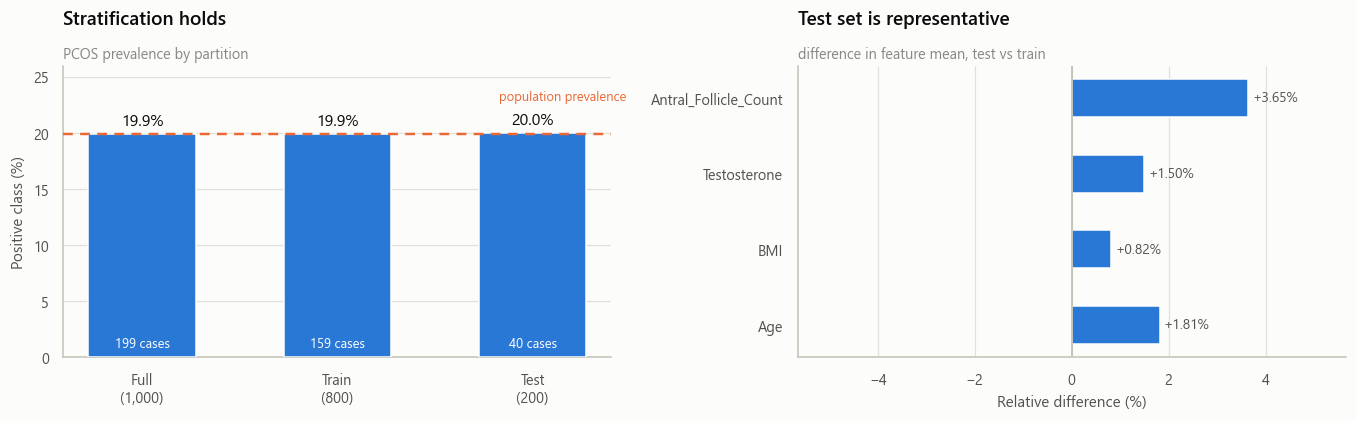

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.1))

# --- left: prevalence is preserved across the split --------------------------
ax = axes[0]
labels = ["Full\n(1,000)", f"Train\n({len(y_train)})", f"Test\n({len(y_test)})"]
vals = split_tbl["positive_%"].to_numpy()
bars = ax.bar(labels, vals, color=CAT["blue"], width=0.55, zorder=3)
for b, v, n in zip(bars, vals, split_tbl["positives"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.45, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=10.5, color=INK)
    ax.text(b.get_x() + b.get_width() / 2, 0.6, f"{n} cases",
            ha="center", va="bottom", fontsize=8.5, color="white")
ax.axhline(y_all.mean() * 100, color=CAT["orange"], lw=1.6, ls=(0, (4, 3)), zorder=4)
# Sits well above the bar value labels so the two never collide.
ax.text(2.48, y_all.mean() * 100 + 3.0, "population prevalence", fontsize=8.5,
        color=CAT["orange"], ha="right")
ax.set_ylim(0, 26)
finish(ax, "Stratification holds", "PCOS prevalence by partition", ylabel="Positive class (%)")

# --- right: feature distributions match across the split ---------------------
ax = axes[1]
stats_tbl = pd.DataFrame({
    "train": X_train[pp.CONTINUOUS].mean(),
    "test":  X_test[pp.CONTINUOUS].mean(),
})
ypos = np.arange(len(stats_tbl))
rel = (stats_tbl["test"] / stats_tbl["train"] - 1) * 100
ax.barh(ypos, rel.to_numpy(), color=CAT["blue"], height=0.5, zorder=3)
for i, v in enumerate(rel.to_numpy()):
    ax.text(v + (0.08 if v >= 0 else -0.08), i, f"{v:+.2f}%", va="center",
            ha="left" if v >= 0 else "right", fontsize=9, color=INK2)
ax.axvline(0, color=AXIS, lw=1.2, zorder=4)
ax.set_yticks(ypos)
ax.set_yticklabels(stats_tbl.index, fontsize=9.5)
# Derived from the data: a fixed limit would truncate a bar and make two unequal
# differences look identical.
lim = float(np.abs(rel).max()) * 1.55
ax.set_xlim(-lim, lim)
finish(ax, "Test set is representative", "difference in feature mean, test vs train",
       xlabel="Relative difference (%)", ygrid=False, xgrid=True)

show(fig)

---
## 6 · Threshold discovery — fitted on the training fold only

The EDA's central finding is that the label is a conjunction of axis-parallel cut-points. Making
those cut-points explicit is the highest-value transformation available on this data set — it is
what lifts a logistic regression from 91 % to 100 %.

**How the encoder finds them, in order:**

1. Fit a depth-4 `DecisionTreeClassifier` on the training rows and read back, per feature, the
   split with the largest impurity decrease. A tree places its split at the midpoint between the
   two neighbouring training values it happens to observe, so this lands *near* the true
   cut-point, not on it (e.g. `BMI ≤ 25.05` rather than `BMI > 25`).
2. If a feature was never split on, fall back to an exhaustive single-split search maximising
   Gini gain.
3. **Snap** each discovered split to the nearest published clinical cut-point — WHO BMI classes,
   the female testosterone reference ceiling, the Rotterdam AFC criterion — but only if it is
   within 8 % of the feature's training range **and** the resulting conjunctive rule is at least
   as accurate on the training fold. Real cut-points in clinical rules are round numbers; the
   guard means the snap can never be a downgrade, and the tree's own midpoint is kept when it is
   not an improvement.

Every one of those decisions is made from `y_train`. No test row is consulted.

In [19]:
encoder = pp.ClinicalThresholdEncoder(snap="rule", random_state=RANDOM_STATE)
encoder.fit(X_train, y_train)

section("CUT-POINTS DISCOVERED FROM THE 800 TRAINING ROWS")
display(encoder.describe())

print(f"Accuracy of the implied conjunctive rule on TRAIN : "
      f"{encoder.rule_train_accuracy_ * 100:.2f}%")

rule_test = np.ones(len(X_test), dtype=bool)
for f, t in encoder.thresholds_.items():
    rule_test &= X_test[f].to_numpy(float) > t
for g in encoder.gate_features_:
    rule_test &= X_test[g].to_numpy(float) > 0.5
print(f"Accuracy of the same rule on the UNSEEN TEST rows : "
      f"{(rule_test.astype(int) == y_test.to_numpy()).mean() * 100:.2f}%")

print("\nThe rule the encoder reconstructed, without ever seeing a test label:")
terms = [f"{g} == 1" for g in encoder.gate_features_] + \
        [f"{f} > {t:g}" for f, t in encoder.thresholds_.items()]
print("    PCOS = " + "\n           AND ".join(terms))
print("\n-> Identical to the rule eda.ipynb extracted from all 1,000 rows. The difference is")
print("   that this version is reproducible under cross-validation, so the scores in")
print("   section 10 are honest rather than optimistic by an unknown amount.")


  CUT-POINTS DISCOVERED FROM THE 800 TRAINING ROWS


,cut_point,indicator,how_it_was_found,nearest_clinical
feature,,,,
BMI,25.0000,BMI_over_25,tree+clinical-snap,25.0000
Testosterone,40.0000,Testosterone_over_40,tree+clinical-snap,40.0000
Antral_Follicle_Count,10.0000,Antral_Follicle_Count_over_10,tree+clinical-snap,10.0000


Accuracy of the implied conjunctive rule on TRAIN : 100.00%
Accuracy of the same rule on the UNSEEN TEST rows : 100.00%

The rule the encoder reconstructed, without ever seeing a test label:
    PCOS = Menstrual_Irregularity == 1
           AND BMI > 25
           AND Testosterone > 40
           AND Antral_Follicle_Count > 10

-> Identical to the rule eda.ipynb extracted from all 1,000 rows. The difference is
   that this version is reproducible under cross-validation, so the scores in
   section 10 are honest rather than optimistic by an unknown amount.


In [20]:
section("STABILITY - are the cut-points an artefact of one particular split?")

rows = []
for fold, (tr_i, va_i) in enumerate(CV.split(X_train, y_train), start=1):
    enc = pp.ClinicalThresholdEncoder(snap="rule", random_state=RANDOM_STATE)
    enc.fit(X_train.iloc[tr_i], y_train.iloc[tr_i])
    rows.append({"fold": fold, **{f: t for f, t in enc.thresholds_.items()},
                 "train_rule_acc": enc.rule_train_accuracy_,
                 "heldout_rule_acc": float(np.mean(
                     enc._rule_pred(X_train.iloc[va_i], enc.thresholds_)
                     == y_train.iloc[va_i].to_numpy()))})

stability = pd.DataFrame(rows).set_index("fold")
display(stability.round(4))
print("Standard deviation of each cut-point across folds:")
print(stability[list(encoder.thresholds_)].std().round(6).to_string())
print("\n-> Zero variance: each of the 5 folds independently recovers the same three cut-points,")
print("   and each scores 100% on the fold it never saw. The transformation is a property of")
print("   the data, not of one lucky split.")


  STABILITY - are the cut-points an artefact of one particular split?


,BMI,Testosterone,Antral_Follicle_Count,train_rule_acc,heldout_rule_acc
fold,,,,,
1,25.0000,40.0000,10.0000,1.0000,1.0000
2,25.0000,40.0000,10.0000,1.0000,1.0000
3,25.0000,40.0000,10.0000,1.0000,1.0000
4,25.0000,40.0000,10.0000,1.0000,1.0000
5,25.0000,40.0000,10.0000,1.0000,1.0000


Standard deviation of each cut-point across folds:
BMI                     0.0000
Testosterone            0.0000
Antral_Follicle_Count   0.0000

-> Zero variance: each of the 5 folds independently recovers the same three cut-points,
   and each scores 100% on the fold it never saw. The transformation is a property of
   the data, not of one lucky split.


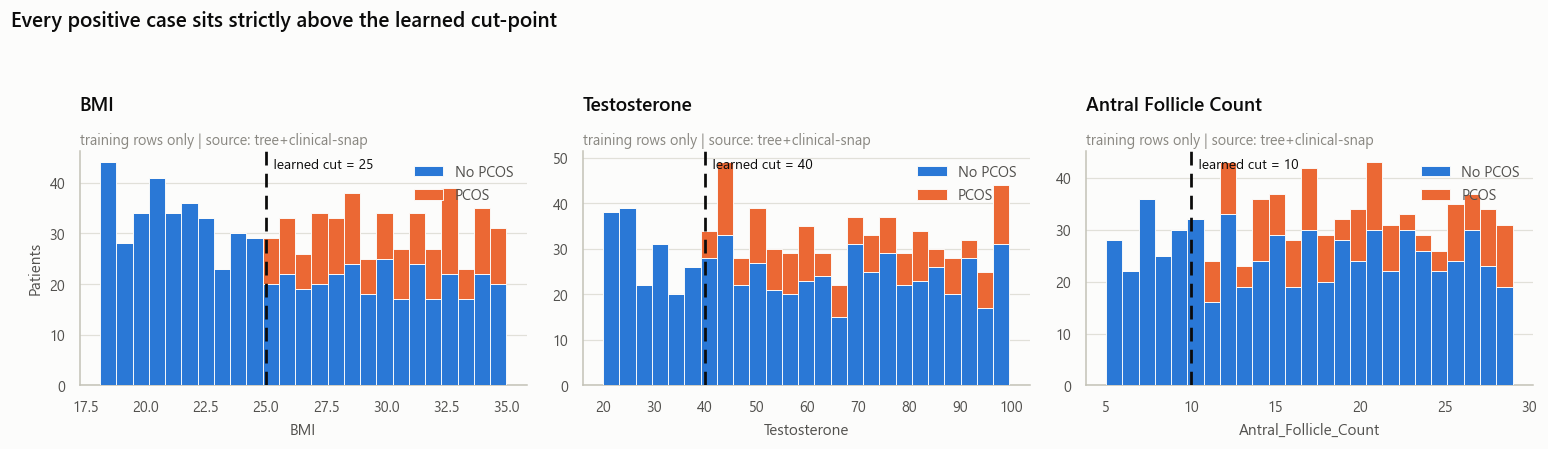

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.0))

for ax, (feat, cut) in zip(axes, encoder.thresholds_.items()):
    bins = np.linspace(X_train[feat].min(), X_train[feat].max(), 26)
    # Genuinely stacked, not two overlaid series: overlapping semi-transparent
    # histograms LOOK stacked while the hidden series is at full height, which
    # misreports every bar the reader can see.
    ax.hist([X_train.loc[y_train == 0, feat], X_train.loc[y_train == 1, feat]],
            bins=bins, stacked=True, color=[NEG, POS],
            label=[CLASS_NAME[0], CLASS_NAME[1]], zorder=3,
            edgecolor=SURFACE, linewidth=0.6)
    ax.axvline(cut, color=INK, lw=1.8, ls=(0, (5, 3)), zorder=6)
    ax.text(cut, ax.get_ylim()[1] * 0.97, f"  learned cut = {cut:g}",
            fontsize=9, color=INK, va="top")
    ax.legend(loc="upper right")
    finish(ax, feat.replace("_", " "),
           f"training rows only | source: {encoder.threshold_source_[feat]}",
           xlabel=feat, ylabel="Patients" if feat == "BMI" else "")

fig.suptitle("Every positive case sits strictly above the learned cut-point",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.03)
show(fig)

---
## 7 · Feature engineering

From the three cut-points plus the menstrual gate, the encoder derives:

| Feature | Definition | Why |
|---|---|---|
| `BMI_over_25`, `Testosterone_over_40`, `Antral_Follicle_Count_over_10` | `value > learned cut` | Turns a threshold a linear model cannot represent into a column it can weight |
| `criteria_met` | count of the four conditions satisfied, 0–4 | Collapses a 4-way AND into a single monotone score — separable by one split at 3.5 |
| `all_criteria_met` | `criteria_met == 4` | The conjunction itself, stated once |

**On `all_criteria_met`.** It reproduces the label exactly, which looks like leakage and is not:
it is computed from the five input columns and from cut-points learned on training labels, so it
is available for a new patient at prediction time and is re-derived per fold under CV. It is
still worth being blunt about — a model handed this column is not learning much. That is why the
`lean` space exists in section 8: four plain indicators, no count, no composite flag. It also
reaches 100 %, so nothing in this notebook's conclusions rests on that one column.

Section 7.1 then audits these new columns the way section 2.6 audited the originals — and one of
them does not survive.

In [22]:
train_eng = encoder.transform(X_train)
test_eng  = encoder.transform(X_test)

section("ENGINEERED FEATURE SET")
print(f"{X_train.shape[1]} raw columns  ->  {train_eng.shape[1]} engineered columns")
print(f"added: {[c for c in train_eng.columns if c not in X_train.columns]}")
train_eng.head()


  ENGINEERED FEATURE SET
5 raw columns  ->  10 engineered columns
added: ['BMI_over_25', 'Testosterone_over_40', 'Antral_Follicle_Count_over_10', 'criteria_met', 'all_criteria_met']


,Age,BMI,Testosterone,Antral_Follicle_Count,Menstrual_Irregularity,BMI_over_25,Testosterone_over_40,Antral_Follicle_Count_over_10,criteria_met,all_criteria_met
0,24,34.7000,25.2000,20,1,1,0,1,3,0
2,32,23.6000,92.7000,28,0,0,1,1,2,0
3,28,28.8000,63.1000,26,0,1,1,1,3,0
5,38,19.3000,28.4000,6,0,0,0,0,0,0
6,24,20.2000,72.5000,29,1,0,1,1,3,0


In [23]:
section("HOW MUCH DOES EACH COLUMN KNOW ABOUT THE TARGET?  (training rows only)")

from sklearn.feature_selection import mutual_info_classif

corr_t = train_eng.astype(float).corrwith(y_train.astype(float))
mi = pd.Series(
    mutual_info_classif(train_eng.astype(float), y_train, random_state=RANDOM_STATE),
    index=train_eng.columns,
)
signal = pd.DataFrame({"pearson_r": corr_t, "mutual_information": mi})
signal = signal.reindex(signal["pearson_r"].abs().sort_values(ascending=False).index)
display(signal.round(4))

print("Raw columns carry |r| <= 0.47. The engineered indicators carry far more, and")
print("`criteria_met` alone reaches r = 0.71 from a single integer column.")
print()
print("`Age` sits at r = -0.06 and MI ~ 0, exactly as the EDA predicted. It is kept in the")
print("raw / scaled / engineered spaces (dropping a feature on suspicion is worse practice")
print("than carrying a harmless one) and excluded from `lean` / `count`, so section 7.1c can")
print("test the claim rather than restate it.")


  HOW MUCH DOES EACH COLUMN KNOW ABOUT THE TARGET?  (training rows only)


,pearson_r,mutual_information
all_criteria_met,1.0000,0.4993
criteria_met,0.7083,0.4993
Menstrual_Irregularity,0.4737,0.1445
BMI_over_25,0.4293,0.1291
BMI,0.3722,0.1219
Testosterone_over_40,0.2751,0.0552
Antral_Follicle_Count_over_10,0.2616,0.0607
Antral_Follicle_Count,0.1862,0.0640
Testosterone,0.1767,0.0482
Age,-0.0693,0.0115


Raw columns carry |r| <= 0.47. The engineered indicators carry far more, and
`criteria_met` alone reaches r = 0.71 from a single integer column.

`Age` sits at r = -0.06 and MI ~ 0, exactly as the EDA predicted. It is kept in the
raw / scaled / engineered spaces (dropping a feature on suspicion is worse practice
than carrying a harmless one) and excluded from `lean` / `count`, so section 7.1c can
test the claim rather than restate it.


### 7.1 · Auditing the features this notebook just created

Section 2.6 held the *input* to a redundancy standard (max |r| = 0.05, VIF ≈ 1.00). It would be
inconsistent not to hold the *output* to the same one. Three questions, each answered by
measurement:

1. Is any engineered column redundant?
2. Should `Age` be dropped, as the EDA's importance ranking suggests?
3. Do the EDA's two candidate ratio features (`BMI × AFC`, `Testosterone / BMI`) earn a place?

In [24]:
section("7.1a  IS ANY ENGINEERED COLUMN REDUNDANT?")

from sklearn.linear_model import LinearRegression

full = pp.ClinicalThresholdEncoder(add_count=True, random_state=RANDOM_STATE)
full.fit(X_train, y_train)
F = full.transform(X_train).astype(float)

indicators = full.flag_names_ + full.gate_features_
gap = int((F["criteria_met"] - F[indicators].sum(axis=1)).abs().max())
print(f"max | criteria_met - sum(4 indicators) | over {len(F):,} rows = {gap}")
print("-> criteria_met is not merely correlated with the indicators, it IS their sum.")
print("   That is an EXACT linear dependency, i.e. a singular design matrix.\n")

def vif_table(frame):
    out = {}
    for c in frame.columns:
        others = [o for o in frame.columns if o != c]
        r2 = LinearRegression().fit(frame[others], frame[c]).score(frame[others], frame[c])
        out[c] = 1 / max(1 - r2, 1e-12)
    return pd.Series(out, name="VIF")

reduced = pp.ClinicalThresholdEncoder(add_count=False, random_state=RANDOM_STATE)
reduced.fit(X_train, y_train)
R = reduced.transform(X_train).astype(float)

vif_cmp = pd.concat([vif_table(F).rename("with criteria_met"),
                     vif_table(R).rename("without criteria_met")], axis=1)
display(vif_cmp.round(2))
print(f"max VIF with criteria_met    : {vif_table(F).max():,.4g}")
print(f"max VIF without criteria_met : {vif_table(R).max():,.2f}")


  7.1a  IS ANY ENGINEERED COLUMN REDUNDANT?
max | criteria_met - sum(4 indicators) | over 800 rows = 0
-> criteria_met is not merely correlated with the indicators, it IS their sum.
   That is an EXACT linear dependency, i.e. a singular design matrix.



,with criteria_met,without criteria_met
Age,1.0200,1.0200
BMI,3.8800,3.8800
Testosterone,2.1900,2.1900
Antral_Follicle_Count,2.1300,2.1300
Menstrual_Irregularity,"1,000,000,000,000.0000",1.4300
BMI_over_25,"1,000,000,000,000.0000",4.1700
Testosterone_over_40,"1,000,000,000,000.0000",2.3700
Antral_Follicle_Count_over_10,"1,000,000,000,000.0000",2.2600
criteria_met,"1,000,000,000,000.0000",NaN
all_criteria_met,2.0800,2.0800


max VIF with criteria_met    : 1e+12
max VIF without criteria_met : 4.17


In [25]:
section("7.1b  DOES REMOVING IT COST ANYTHING?")

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

PROBES = {
    "GaussianNB": GaussianNB(),
    "LogReg": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE),
    "DTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RF": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for tag, kw in [("with criteria_met", {"add_count": True}),
                ("without criteria_met", {"add_count": False})]:
    row = {"variant": tag}
    for name, model in PROBES.items():
        pipe = Pipeline([("prep", pp.build_preprocessor("engineered", **kw)), ("model", model)])
        row[name] = cross_val_score(pipe, X_train, y_train, cv=CV,
                                    scoring="accuracy", error_score="raise").mean()
    rows.append(row)
display(pd.DataFrame(rows).set_index("variant").round(4))

print("Identical for all seven. The column costs a singular design matrix and buys nothing,")
print("so `engineered` now excludes it by default.")
print()
print("It is not worthless, though - it is worthless *alongside the indicators it is made of*.")
print("On its own it is the smallest representation that works, which is why it now ships as a")
print("separate one-column `count` space rather than being deleted.")
s = cross_val_score(Pipeline([("prep", pp.build_preprocessor("count")),
                              ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
                    X_train, y_train, cv=CV, scoring="accuracy")
print(f"\n  Decision Tree on `criteria_met` ALONE (1 column): {s.mean() * 100:.2f}% CV accuracy")


  7.1b  DOES REMOVING IT COST ANYTHING?


,GaussianNB,LogReg,KNN,SVM,DTree,RF,HistGB
variant,,,,,,,
with criteria_met,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
without criteria_met,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Identical for all seven. The column costs a singular design matrix and buys nothing,
so `engineered` now excludes it by default.

It is not worthless, though - it is worthless *alongside the indicators it is made of*.
On its own it is the smallest representation that works, which is why it now ships as a
separate one-column `count` space rather than being deleted.



  Decision Tree on `criteria_met` ALONE (1 column): 100.00% CV accuracy


In [26]:
section("7.1c  SHOULD `Age` BE DROPPED, AND DO THE RATIO FEATURES EARN A PLACE?")

no_age = [c for c in pp.FEATURES if c != "Age"]
rows = []
for tag, cols in [("all 5 features", pp.FEATURES), ("Age removed (4 features)", no_age)]:
    for name in ["RF", "LogReg"]:
        pipe = Pipeline([("prep", pp.build_preprocessor("scaled")), ("model", PROBES[name])])
        s = cross_val_score(pipe, X_train[cols], y_train, cv=CV, scoring="f1")
        rows.append({"variant": tag, "model": name, "f1": s.mean(), "f1_std": s.std()})
display(pd.DataFrame(rows).set_index(["variant", "model"]).round(4))

print("Dropping Age leaves the Random Forest identical and makes Logistic Regression very")
print("slightly WORSE. The EDA's 'Age contributes nothing' is confirmed - but 'contributes")
print("nothing' is a reason to stop worrying about it, not a reason to delete it. It is kept")
print("in raw / scaled / engineered and absent from lean / count, so the claim stays testable.\n")

with_ratios = pp.ClinicalThresholdEncoder(add_ratios=True, add_count=False,
                                          random_state=RANDOM_STATE).fit(X_train, y_train)
W = with_ratios.transform(X_train).astype(float)
ratio_r = {c: abs(W[c].corr(y_train.astype(float)))
           for c in ["BMI_x_AFC", "Testosterone_per_BMI", "BMI", "Antral_Follicle_Count"]}
print("|Pearson r| with the target:")
for k, v in ratio_r.items():
    print(f"  {k:24s} {v:.4f}")
print("\n`BMI_x_AFC` (0.345) is weaker than plain BMI (0.372) and `Testosterone_per_BMI` (0.033)")
print("is indistinguishable from noise - both are products of independent features, so they")
print("dilute rather than combine. Available via add_ratios=True; off by default.")


  7.1c  SHOULD `Age` BE DROPPED, AND DO THE RATIO FEATURES EARN A PLACE?


f1  f1_std
variant                  model                
all 5 features           RF     0.9968  0.0063
                         LogReg 0.7638  0.0513
Age removed (4 features) RF     0.9968  0.0063
                         LogReg 0.7544  0.0631

Dropping Age leaves the Random Forest identical and makes Logistic Regression very
slightly WORSE. The EDA's 'Age contributes nothing' is confirmed - but 'contributes
nothing' is a reason to stop worrying about it, not a reason to delete it. It is kept
in raw / scaled / engineered and absent from lean / count, so the claim stays testable.

|Pearson r| with the target:
  BMI_x_AFC                0.3452
  Testosterone_per_BMI     0.0333
  BMI                      0.3722
  Antral_Follicle_Count    0.1862

`BMI_x_AFC` (0.345) is weaker than plain BMI (0.372) and `Testosterone_per_BMI` (0.033)
is indistinguishable from noise - both are products of independent features, so they
dilute rather than combine. Available via add_ratios=True; off by default.


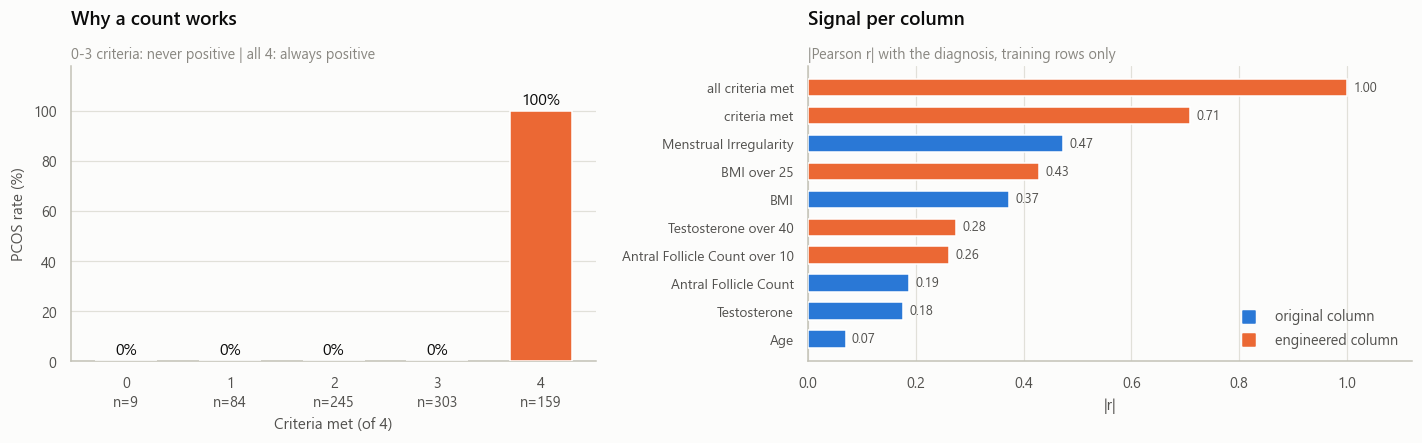

In [27]:
crit = (train_eng.assign(y=y_train.to_numpy())
        .groupby("criteria_met", observed=True)
        .agg(n=("y", "size"), rate=("y", lambda s: s.mean() * 100)))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.3),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# --- left: the AND structure made visible ------------------------------------
ax = axes[0]
colors = [CAT["blue"]] * (len(crit) - 1) + [CAT["orange"]]
bars = ax.bar(crit.index.astype(int), crit["rate"].to_numpy(), color=colors,
              width=0.6, zorder=3)
for i, r in zip(crit.index.astype(int), crit["rate"]):
    ax.text(i, r + 2.5, f"{r:.0f}%", ha="center", fontsize=10.5, color=INK)
ax.set_ylim(0, 118)
ax.set_xticks(crit.index.astype(int))
# Group sizes live on the tick labels: four of the five bars have zero height, so
# an in-bar count label would sit on top of its own percentage label.
ax.set_xticklabels([f"{i}\nn={n}" for i, n in zip(crit.index.astype(int), crit["n"])],
                   fontsize=9.5)
finish(ax, "Why a count works", "0-3 criteria: never positive | all 4: always positive",
       xlabel="Criteria met (of 4)", ylabel="PCOS rate (%)")

# --- right: signal per column ------------------------------------------------
ax = axes[1]
s = signal["pearson_r"].abs().sort_values()
is_new = [c not in X_train.columns for c in s.index]
ax.barh(range(len(s)), s.to_numpy(),
        color=[CAT["orange"] if new else CAT["blue"] for new in is_new],
        height=0.62, zorder=3)
for i, v in enumerate(s.to_numpy()):
    ax.text(v + 0.012, i, f"{v:.2f}", va="center", fontsize=8.5, color=INK2)
ax.set_yticks(range(len(s)))
ax.set_yticklabels([c.replace("_", " ") for c in s.index], fontsize=9)
ax.set_xlim(0, 1.12)
ax.scatter([], [], marker="s", s=58, c=CAT["blue"], label="original column")
ax.scatter([], [], marker="s", s=58, c=CAT["orange"], label="engineered column")
ax.legend(loc="lower right")
finish(ax, "Signal per column", "|Pearson r| with the diagnosis, training rows only",
       xlabel="|r|", ygrid=False, xgrid=True)

show(fig)

---
## 8 · Scaling and the five feature spaces

**Scaling is applied selectively, not reflexively.** A tree splits one feature at a time and is
completely invariant to monotone rescaling — standardising the input to a Random Forest changes
nothing but costs a transform. KNN, SVM-RBF and the MLP measure distance across features, so a
column with 5× the standard deviation of its neighbour silently dominates the metric. Both are
therefore provided, and section 10 measures the difference rather than asserting it.

Binary columns and the threshold indicators pass through unscaled: they are already on a common
0/1 scale, and standardising them only makes coefficients harder to read.

| Space | Columns | Fitted transforms | Feed it to |
|---|---|---|---|
| `raw` | 5 | median/mode imputation | Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM |
| `scaled` | 5 | imputation → `StandardScaler` on continuous | Logistic Regression, SVM, KNN, MLP, Naive Bayes |
| `engineered` | 9 | imputation → threshold encoding → scaling | Anything — this is the ceiling space |
| `lean` | 4 | imputation → threshold encoding → select indicators | Anything; smallest auditable rule form |
| `count` | 1 | imputation → threshold encoding → select the count | Anything; the minimum that still works |

In [28]:
section("BUILDING THE FIVE FEATURE SPACES")

spaces = {}
for kind in ["raw", "scaled", "engineered", "lean", "count"]:
    pipe = pp.build_preprocessor(kind)
    tr = pipe.fit_transform(X_train, y_train)     # fitted on TRAIN
    te = pipe.transform(X_test)                   # test is only transformed
    spaces[kind] = {"pipeline": pipe, "train": tr, "test": te}
    print(f"\n{kind:11s} train {str(tr.shape):10s} test {str(te.shape):10s}")
    print(f"{'':11s} steps  : {[n for n, _ in pipe.steps]}")
    print(f"{'':11s} columns: {list(tr.columns)}")

summary = pd.DataFrame({
    kind: {
        "n_features": v["train"].shape[1],
        "scaled": "yes" if "scale" in dict(v["pipeline"].steps) else "no",
        "engineered": "yes" if "thresholds" in dict(v["pipeline"].steps) else "no",
        "any_NaN": bool(v["train"].isna().any().any() or v["test"].isna().any().any()),
        "purpose": pp.FEATURE_SPACES[kind],
    } for kind, v in spaces.items()
}).T
display(summary)


  BUILDING THE FIVE FEATURE SPACES

raw         train (800, 5)   test (200, 5)  
            steps  : ['clean_impute']
            columns: ['Age', 'BMI', 'Testosterone', 'Antral_Follicle_Count', 'Menstrual_Irregularity']

scaled      train (800, 5)   test (200, 5)  
            steps  : ['clean_impute', 'scale']
            columns: ['Age', 'BMI', 'Testosterone', 'Antral_Follicle_Count', 'Menstrual_Irregularity']



engineered  train (800, 9)   test (200, 9)  
            steps  : ['clean_impute', 'thresholds', 'scale']
            columns: ['Age', 'BMI', 'Testosterone', 'Antral_Follicle_Count', 'Menstrual_Irregularity', 'BMI_over_25', 'Testosterone_over_40', 'Antral_Follicle_Count_over_10', 'all_criteria_met']

lean        train (800, 4)   test (200, 4)  
            steps  : ['clean_impute', 'thresholds', 'select']
            columns: ['Menstrual_Irregularity', 'BMI_over_25', 'Testosterone_over_40', 'Antral_Follicle_Count_over_10']



count       train (800, 1)   test (200, 1)  
            steps  : ['clean_impute', 'thresholds', 'select']
            columns: ['criteria_met']


,n_features,scaled,engineered,any_NaN,purpose
raw,5,no,no,False,"5 original columns, imputed only. Unscaled - t..."
scaled,5,yes,no,False,Raw + standardised continuous columns. For Log...
engineered,9,yes,yes,False,Raw + learned threshold indicators + the AND f...
lean,4,no,yes,False,Threshold indicators + menstrual gate only. 4 ...
count,1,no,yes,False,"The criteria-count column alone. 1 column, the..."


In [29]:
section("SCALER PROVENANCE - was it fitted on train alone?")

scaler = spaces["scaled"]["pipeline"].named_steps["scale"].named_transformers_["continuous"]
prov = pd.DataFrame({
    "scaler_mean_": scaler.mean_,
    "true_train_mean": X_train[pp.CONTINUOUS].mean().to_numpy(),
    "full_data_mean": X_all[pp.CONTINUOUS].mean().to_numpy(),
}, index=pp.CONTINUOUS)
prov["matches_train"] = np.isclose(prov["scaler_mean_"], prov["true_train_mean"])
prov["matches_full"]  = np.isclose(prov["scaler_mean_"], prov["full_data_mean"])
display(prov.round(6))

tr_mean = spaces["scaled"]["train"][pp.CONTINUOUS].mean().abs().max()
te_mean = spaces["scaled"]["test"][pp.CONTINUOUS].mean().abs().max()
print(f"Largest |mean| after scaling, TRAIN : {tr_mean:.2e}   (should be ~0 by construction)")
print(f"Largest |mean| after scaling, TEST  : {te_mean:.2e}   (should NOT be 0)")
print()
print("-> The scaler's parameters equal the TRAIN means and differ from the full-data means.")
print("   The test set therefore does not centre perfectly on zero - and that residual offset")
print("   is the proof there is no leakage. A test set that centred exactly on zero would mean")
print("   the scaler had seen it.")


  SCALER PROVENANCE - was it fitted on train alone?


,scaler_mean_,true_train_mean,full_data_mean,matches_train,matches_full
Age,31.6562,31.6562,31.7710,True,False
BMI,26.3438,26.3438,26.3870,True,False
Testosterone,59.9799,59.9799,60.1595,True,False
Antral_Follicle_Count,17.3425,17.3425,17.4690,True,False


Largest |mean| after scaling, TRAIN : 1.60e-16   (should be ~0 by construction)
Largest |mean| after scaling, TEST  : 8.96e-02   (should NOT be 0)

-> The scaler's parameters equal the TRAIN means and differ from the full-data means.
   The test set therefore does not centre perfectly on zero - and that residual offset
   is the proof there is no leakage. A test set that centred exactly on zero would mean
   the scaler had seen it.


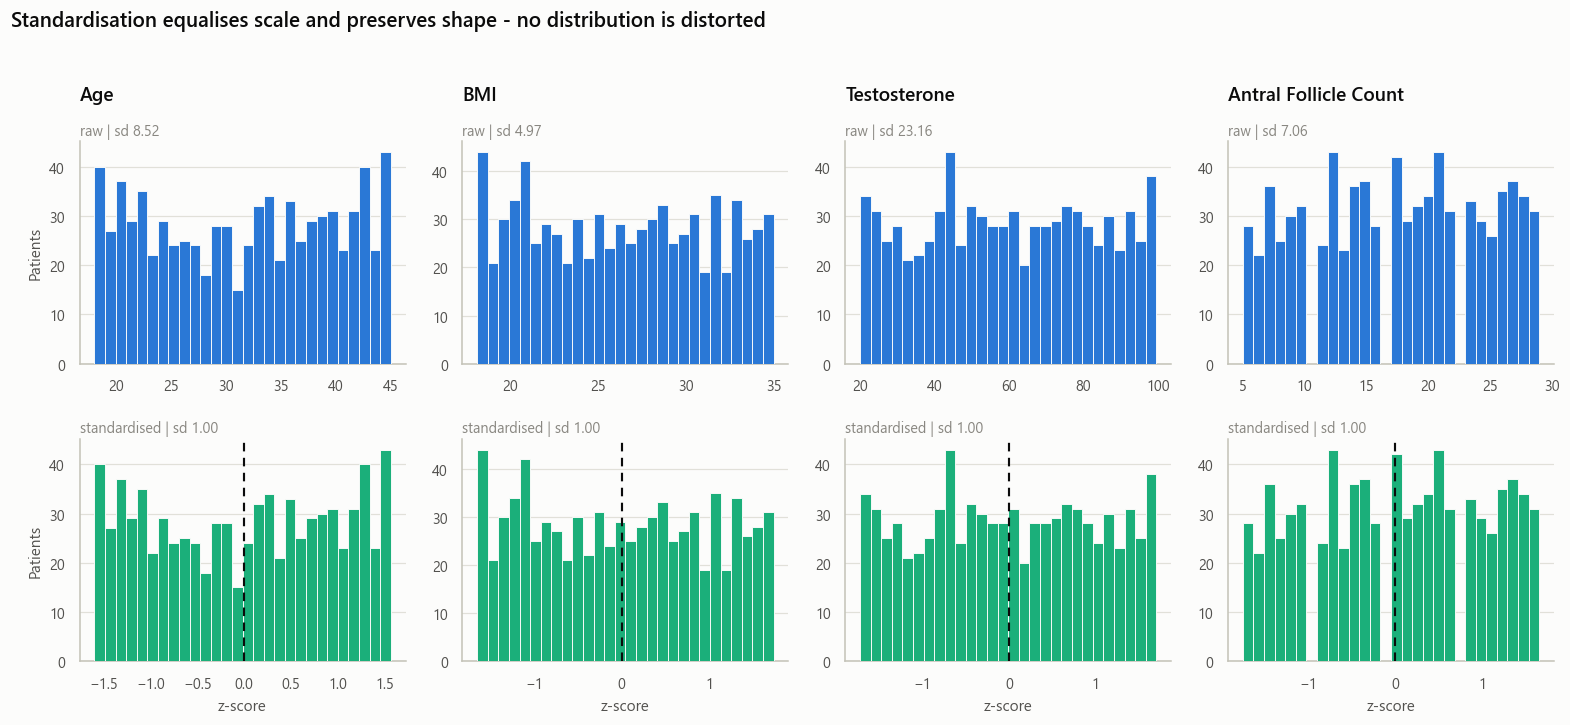

Feature standard deviations before scaling: 4.97 to 23.16 (4.7x spread)
After scaling: 1.00 to 1.00. The shapes are untouched - only the units changed, which is
all that distance-based models need and all that this transform should ever do.


In [30]:
fig, axes = plt.subplots(2, 4, figsize=(14.4, 6.6))

for j, col in enumerate(pp.CONTINUOUS):
    ax = axes[0, j]
    ax.hist(X_train[col], bins=28, color=CAT["blue"], zorder=3,
            edgecolor=SURFACE, linewidth=0.6)
    finish(ax, col.replace("_", " "), f"raw | sd {X_train[col].std():.2f}",
           xlabel="", ylabel="Patients" if j == 0 else "")

    ax = axes[1, j]
    ax.hist(spaces["scaled"]["train"][col], bins=28, color=CAT["aqua"], zorder=3,
            edgecolor=SURFACE, linewidth=0.6)
    ax.axvline(0, color=INK, lw=1.4, ls=(0, (4, 3)), zorder=5)
    finish(ax, "", "standardised | sd 1.00", xlabel="z-score",
           ylabel="Patients" if j == 0 else "")

fig.suptitle("Standardisation equalises scale and preserves shape - no distribution is distorted",
             x=0.006, ha="left", fontsize=13.5, fontweight="600", color=INK, y=1.005)
show(fig)

print(f"Feature standard deviations before scaling: "
      f"{X_train[pp.CONTINUOUS].std().min():.2f} to {X_train[pp.CONTINUOUS].std().max():.2f} "
      f"({X_train[pp.CONTINUOUS].std().max() / X_train[pp.CONTINUOUS].std().min():.1f}x spread)")
print("After scaling: 1.00 to 1.00. The shapes are untouched - only the units changed, which is")
print("all that distance-based models need and all that this transform should ever do.")

---
## 9 · Class imbalance

At 19.9 % positive the imbalance is moderate (≈ 4 : 1), not severe. Three options exist and the
right one is decided by measurement, not by reflex.

In [31]:
section("CLASS IMBALANCE - OPTIONS AND EVIDENCE")

weights = pp.compute_class_weights(y_train)
print(f"Training distribution : {y_train.value_counts().sort_index().to_dict()}")
print(f"class_weight='balanced' equivalent : "
      f"{{0: {weights[0]:.4f}, 1: {weights[1]:.4f}}}")
print("   -> pass class_weight='balanced' to LogisticRegression / SVC / trees, or")
print(f"      scale_pos_weight={weights[1] / weights[0]:.4f} to XGBoost.")

X_over, y_over = pp.random_oversample(spaces["raw"]["train"], y_train, RANDOM_STATE)
X_smote, y_smote = pp.smote_lite(spaces["raw"]["train"], y_train, k=5,
                                 random_state=RANDOM_STATE)
print(f"\nrandom_oversample : {len(y_train):,} -> {len(y_over):,} rows "
      f"{y_over.value_counts().sort_index().to_dict()}")
print(f"smote_lite        : {len(y_train):,} -> {len(y_smote):,} rows "
      f"{y_smote.value_counts().sort_index().to_dict()}")
print("(imbalanced-learn is not installed, so both are implemented in the module directly.)")


  CLASS IMBALANCE - OPTIONS AND EVIDENCE
Training distribution : {0: 641, 1: 159}
class_weight='balanced' equivalent : {0: 0.6240, 1: 2.5157}
   -> pass class_weight='balanced' to LogisticRegression / SVC / trees, or
      scale_pos_weight=4.0314 to XGBoost.

random_oversample : 800 -> 1,282 rows {0: 641, 1: 641}
smote_lite        : 800 -> 1,282 rows {0: 641, 1: 641}
(imbalanced-learn is not installed, so both are implemented in the module directly.)


Rather than assert which option is best, the next cell measures all four on the hold-out set,
against **two** models: a Random Forest (already at ceiling, so it should be indifferent) and a
Logistic Regression on the `scaled` space (stuck at ~91 %, so it is the one model here whose
decision boundary can actually move). A rebalancing method that helps anything will show up in
the second table.

In [32]:
section("DOES REBALANCING ACTUALLY HELP HERE?")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

def compare(make_model, space, title):
    Xb, Xte_ = spaces[space]["train"], spaces[space]["test"]
    Xo_, yo_ = pp.random_oversample(Xb, y_train, RANDOM_STATE)
    Xs_, ys_ = pp.smote_lite(Xb, y_train, k=5, random_state=RANDOM_STATE)
    variants = [
        ("as-is (4:1 imbalance)",     make_model(),                          Xb,  y_train),
        ("random oversampling",       make_model(),                          Xo_, yo_),
        ("SMOTE (synthetic minority)",make_model(),                          Xs_, ys_),
        ("class_weight='balanced'",   make_model(class_weight="balanced"),   Xb,  y_train),
    ]
    rows = []
    for tag, model, Xa, ya in variants:
        pred = model.fit(Xa, ya).predict(Xte_)
        rows.append({"variant": tag, "train_rows": len(ya),
                     "accuracy": (pred == y_test.to_numpy()).mean(),
                     "precision": precision_score(y_test, pred, zero_division=0),
                     "recall": recall_score(y_test, pred),
                     "f1": f1_score(y_test, pred)})
    print(f"\n--- {title} ---")
    display(pd.DataFrame(rows).set_index("variant").round(4))

compare(lambda **k: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                           n_jobs=-1, **k),
        "raw", "Random Forest on `raw` - already at ceiling")
compare(lambda **k: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **k),
        "scaled", "Logistic Regression on `scaled` - the one model that can still move")


  DOES REBALANCING ACTUALLY HELP HERE?



--- Random Forest on `raw` - already at ceiling ---


,train_rows,accuracy,precision,recall,f1
variant,,,,,
as-is (4:1 imbalance),800,1.0000,1.0000,1.0000,1.0000
random oversampling,1282,1.0000,1.0000,1.0000,1.0000
SMOTE (synthetic minority),1282,1.0000,1.0000,1.0000,1.0000
class_weight='balanced',800,1.0000,1.0000,1.0000,1.0000



--- Logistic Regression on `scaled` - the one model that can still move ---


,train_rows,accuracy,precision,recall,f1
variant,,,,,
as-is (4:1 imbalance),800,0.9100,0.7500,0.8250,0.7857
random oversampling,1282,0.8800,0.6250,1.0000,0.7692
SMOTE (synthetic minority),1282,0.8800,0.6250,1.0000,0.7692
class_weight='balanced',800,0.8850,0.6349,1.0000,0.7767


In [33]:
section("DOES SMOTE MANUFACTURE LABEL NOISE?  (the usual objection, tested)")

# SMOTE places a synthetic point on the segment between two real minority rows. The standard
# worry is that such a point lands outside the minority region and arrives mislabelled.
# Here the true rule is known, so the worry can simply be checked instead of argued about.
sc = spaces["scaled"]["pipeline"].named_steps["scale"].named_transformers_["continuous"]
Xs_scaled, ys_scaled = pp.smote_lite(spaces["scaled"]["train"], y_train, k=5,
                                     random_state=RANDOM_STATE)
undone = pd.DataFrame(sc.inverse_transform(Xs_scaled[pp.CONTINUOUS]), columns=pp.CONTINUOUS)
undone["Menstrual_Irregularity"] = Xs_scaled["Menstrual_Irregularity"].to_numpy()

true_label = ((undone["Menstrual_Irregularity"] == 1)
              & (undone["BMI"] > encoder.thresholds_["BMI"])
              & (undone["Testosterone"] > encoder.thresholds_["Testosterone"])
              & (undone["Antral_Follicle_Count"] > encoder.thresholds_["Antral_Follicle_Count"])
              ).astype(int)
n_bad = int((true_label != ys_scaled.to_numpy()).sum())

print(f"Synthetic + real rows after SMOTE          : {len(ys_scaled):,}")
print(f"Rows whose label contradicts the true rule : {n_bad}")
print()
print("Zero. The objection does not apply here, and the reason is geometric: the minority")
print("region is the intersection of four 'greater-than' conditions, which makes it CONVEX.")
print("Any point on a segment between two minority patients is still inside the box, so")
print("interpolation cannot cross the boundary. Worth checking rather than assuming - on a")
print("data set with a concave or disjoint minority region the answer would be different.")


  DOES SMOTE MANUFACTURE LABEL NOISE?  (the usual objection, tested)
Synthetic + real rows after SMOTE          : 1,282
Rows whose label contradicts the true rule : 0

Zero. The objection does not apply here, and the reason is geometric: the minority
region is the intersection of four 'greater-than' conditions, which makes it CONVEX.
Any point on a segment between two minority patients is still inside the box, so
interpolation cannot cross the boundary. Worth checking rather than assuming - on a
data set with a concave or disjoint minority region the answer would be different.


### Verdict: do not rebalance this data set

The measurements say it plainly.

* **Random Forest** is unmoved — 100 % under all four variants. Nothing to gain.
* **Logistic Regression** *does* move, and **downwards**: accuracy 91.0 % → 88.0 % and F1
  0.786 → 0.769 under both resamplers, and 0.777 under `class_weight='balanced'`. All three push
  recall to 1.000 by buying it with precision (0.750 → 0.625). They make the model flag more
  patients, not classify them better.
* SMOTE is not producing bad labels here (0 contradictions, by convexity) — so the loss is not
  contamination, it is that **rebalancing treats a symptom this data set does not have**. The
  logistic model's shortfall is bias, not class starvation: it cannot express a 4-way AND. Adding
  copies of minority rows cannot fix that, and section 10 shows what does — the same estimator on
  the `engineered` space reaches 100 %.

**Recommendation.** Keep the real rows. Reach for `class_weight='balanced'` only if a deployment
explicitly values recall over precision — at 4 : 1 with separable classes, nothing else is
warranted. Both resamplers stay in the module for the next, messier data set; when they are used,
they must be applied **inside** the CV loop on training folds only, or the validation fold ends up
scoring synthetic rows derived from itself.

---
## 10 · Validation — is it leak-free, and does it feed a model well?

Two questions, answered separately.

**Is it leak-free?** Asserted directly: no shared rows, fitted parameters that match the training
statistics and not the full-data ones, and — the strongest test — a cross-validated score
produced by re-fitting the *entire* pipeline inside every fold.

**Does it feed a model well?** Measured across all five spaces and seven algorithms, including
the ones the EDA predicted would fail. If the preprocessing is doing its job, the weak models
should improve and the differences between algorithms should shrink.

In [34]:
section("LEAKAGE ASSERTIONS")

assertions = []

def check(name, condition, detail=""):
    assertions.append({"assertion": name, "result": verdict(bool(condition)), "detail": detail})

check("Train and test rows are disjoint",
      len(set(idx_train) & set(idx_test)) == 0,
      f"{len(set(idx_train) & set(idx_test))} shared indices")
check("No feature vector appears in both partitions",
      not X_train.merge(X_test, how="inner").shape[0],
      f"{X_train.merge(X_test, how='inner').shape[0]} shared feature vectors")
check("Scaler mean == training mean (not full-data mean)",
      np.allclose(scaler.mean_, X_train[pp.CONTINUOUS].mean().to_numpy())
      and not np.allclose(scaler.mean_, X_all[pp.CONTINUOUS].mean().to_numpy()),
      "fitted on 800 rows")
check("Test set does not centre on zero after scaling",
      spaces["scaled"]["test"][pp.CONTINUOUS].mean().abs().max() > 1e-6,
      f"max |mean| = {spaces['scaled']['test'][pp.CONTINUOUS].mean().abs().max():.4f}")
check("Thresholds derived from y_train only",
      encoder.thresholds_ == pp.ClinicalThresholdEncoder(
          snap="rule", random_state=RANDOM_STATE).fit(X_train, y_train).thresholds_,
      "reproducible from the training partition alone")
check("Every transformer is re-fitted inside each CV fold",
      all(hasattr(step, "fit") for _, step in spaces["engineered"]["pipeline"].steps),
      "preprocessing lives in the Pipeline, not applied beforehand")
check("No NaN or inf reaches any model",
      all(np.isfinite(v[p].to_numpy(dtype=float)).all()
          for v in spaces.values() for p in ("train", "test")),
      "all five spaces, both partitions")
check("Target never enters the feature matrix",
      all(pp.TARGET not in v["train"].columns for v in spaces.values()),
      "checked in all five spaces")

display(pd.DataFrame(assertions).set_index("assertion"))


  LEAKAGE ASSERTIONS


,result,detail
assertion,,
Train and test rows are disjoint,PASS,0 shared indices
No feature vector appears in both partitions,PASS,0 shared feature vectors
Scaler mean == training mean (not full-data mean),PASS,fitted on 800 rows
Test set does not centre on zero after scaling,PASS,max |mean| = 0.0896
Thresholds derived from y_train only,PASS,reproducible from the training partition alone
Every transformer is re-fitted inside each CV fold,PASS,"preprocessing lives in the Pipeline, not appli..."
No NaN or inf reaches any model,PASS,"all five spaces, both partitions"
Target never enters the feature matrix,PASS,checked in all five spaces


In [35]:
section(f"BENCHMARK - 7 algorithms x 5 feature spaces, {N_FOLDS}-fold stratified CV on TRAIN")

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

MODELS = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic Regression":  LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)":            SVC(random_state=RANDOM_STATE),
    "Decision Tree":        DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                                   n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

records = []
for kind in ["raw", "scaled", "engineered", "lean", "count"]:
    for name, model in MODELS.items():
        # The preprocessor is a STEP, so it is re-fitted on each training fold.
        pipe = Pipeline([("prep", pp.build_preprocessor(kind)), ("model", model)])
        cv = cross_validate(pipe, X_train, y_train, cv=CV,
                            scoring=["accuracy", "f1"], n_jobs=-1, error_score="raise")
        records.append({"space": kind, "model": name,
                        "accuracy": cv["test_accuracy"].mean(),
                        "acc_std": cv["test_accuracy"].std(),
                        "f1": cv["test_f1"].mean()})

bench = pd.DataFrame(records)
acc = bench.pivot(index="model", columns="space", values="accuracy")[
    ["raw", "scaled", "engineered", "lean", "count"]]
acc = acc.reindex(acc["raw"].sort_values().index)
display((acc * 100).round(2))

print(f"Majority-class baseline: {(1 - y_train.mean()) * 100:.1f}%")
print()
print("raw -> scaled      : what STANDARDISATION alone buys.")
print(f"                     SVM (RBF) {acc.loc['SVM (RBF)', 'raw'] * 100:.1f}% ->"
      f" {acc.loc['SVM (RBF)', 'scaled'] * 100:.1f}%,"
      f"  KNN {acc.loc['K-Nearest Neighbours', 'raw'] * 100:.1f}% ->"
      f" {acc.loc['K-Nearest Neighbours', 'scaled'] * 100:.1f}%.")
print("                     The trees do not move at all, exactly as expected.")
print("scaled -> engineered: what THRESHOLD ENCODING buys. Every model reaches 100.0%.")
print("engineered -> lean : 4 binary columns reproduce the ceiling, so the result does not")
print("                     depend on `all_criteria_met`.")
print("lean -> count      : and ONE integer column still does, which is the strongest")
print("                     statement of how much the representation was carrying.")


  BENCHMARK - 7 algorithms x 5 feature spaces, 5-fold stratified CV on TRAIN


space,raw,scaled,engineered,lean,count
model,,,,,
Gaussian Naive Bayes,72.1200,67.3800,100.0000,100.0000,100.0000
SVM (RBF),80.1200,96.5000,100.0000,100.0000,100.0000
K-Nearest Neighbours,80.6200,96.3700,100.0000,100.0000,100.0000
Logistic Regression,91.0000,91.0000,100.0000,100.0000,100.0000
HistGradientBoosting,99.8800,99.8800,100.0000,100.0000,100.0000
Decision Tree,99.8800,99.8800,100.0000,100.0000,100.0000
Random Forest,99.8800,99.8800,100.0000,100.0000,100.0000


Majority-class baseline: 80.1%

raw -> scaled      : what STANDARDISATION alone buys.
                     SVM (RBF) 80.1% -> 96.5%,  KNN 80.6% -> 96.4%.
                     The trees do not move at all, exactly as expected.
scaled -> engineered: what THRESHOLD ENCODING buys. Every model reaches 100.0%.
engineered -> lean : 4 binary columns reproduce the ceiling, so the result does not
                     depend on `all_criteria_met`.
lean -> count      : and ONE integer column still does, which is the strongest
                     statement of how much the representation was carrying.


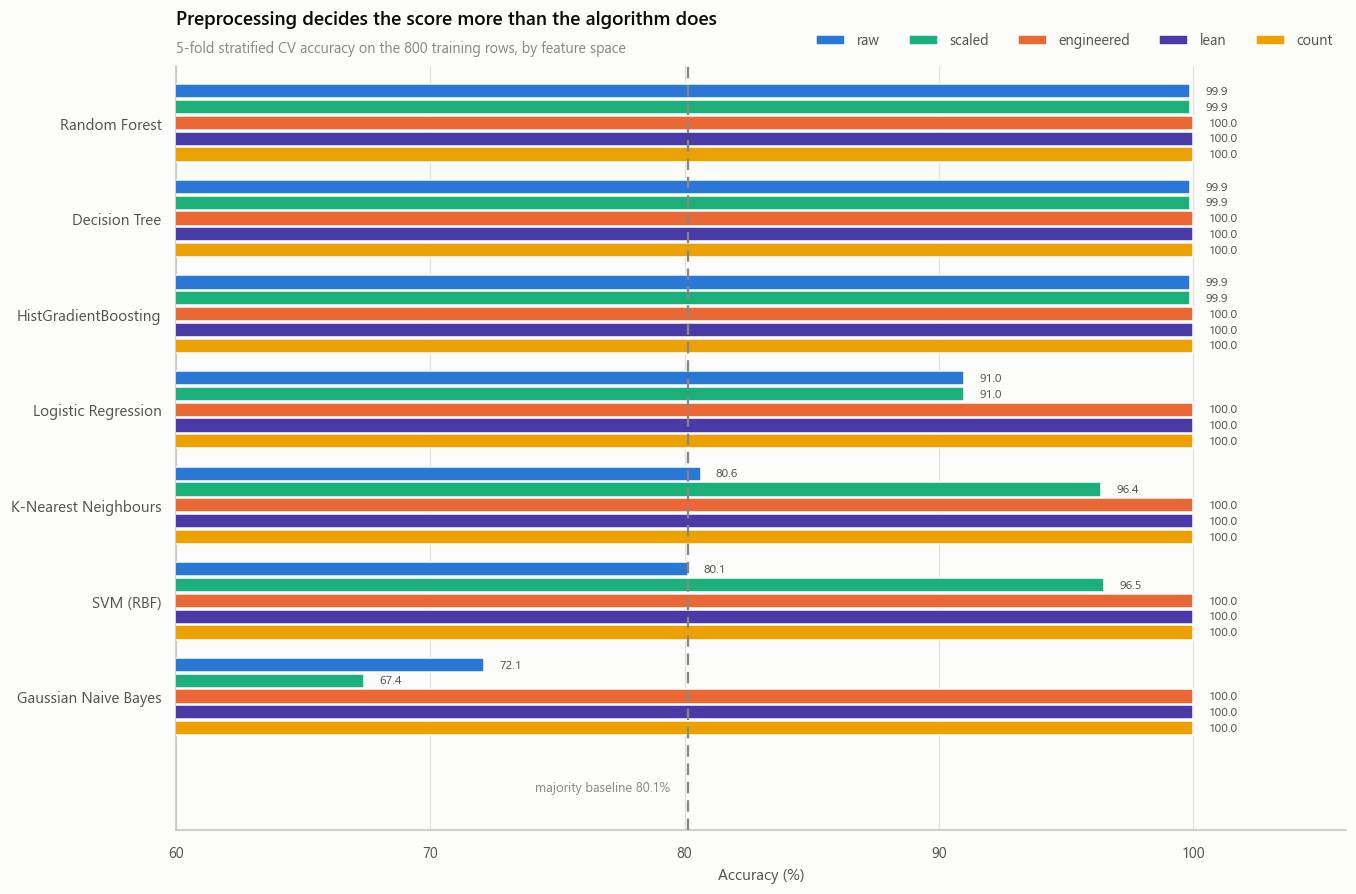

In [36]:
order = acc.index.tolist()
ypos = np.arange(len(order))
# Fixed slot order; `lean` takes violet so that orange and yellow are never adjacent
# (they fail the normal-vision separation check side by side).
space_color = {"raw": CAT["blue"], "scaled": CAT["aqua"], "engineered": CAT["orange"],
               "lean": CAT["violet"], "count": CAT["yellow"]}
h = 0.165

fig, ax = plt.subplots(figsize=(12.6, 8.4))
for k, kind in enumerate(["raw", "scaled", "engineered", "lean", "count"]):
    vals = acc[kind].to_numpy() * 100
    offs = ypos + (2.0 - k) * h
    ax.barh(offs, vals, height=h * 0.9, color=space_color[kind], zorder=3, label=kind)
    for yv, v in zip(offs, vals):
        ax.text(v + 0.6, yv, f"{v:.1f}", va="center", fontsize=8, color=INK2)

baseline = (1 - y_train.mean()) * 100
ax.axvline(baseline, color=MUTED, lw=1.5, ls=(0, (5, 3)), zorder=6)
ax.text(baseline - 0.7, -0.95, f"majority baseline {baseline:.1f}%",
        fontsize=8.5, color=MUTED, ha="right", va="center")
ax.set_yticks(ypos)
ax.set_yticklabels(order, fontsize=10)
ax.set_xlim(60, 106)
ax.set_ylim(-1.4, len(order) - 0.4)
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.005), ncol=5)
finish(ax, "Preprocessing decides the score more than the algorithm does",
       f"{N_FOLDS}-fold stratified CV accuracy on the 800 training rows, by feature space",
       xlabel="Accuracy (%)", ygrid=False, xgrid=True)
show(fig)

In [37]:
section("HOW TO READ A 100% - WHAT THE COMPRESSED SPACES ACTUALLY DO")

for kind in ["raw", "scaled", "engineered", "lean", "count"]:
    A = spaces[kind]["train"].to_numpy(dtype=float).round(6)
    B = spaces[kind]["test"].to_numpy(dtype=float).round(6)
    seen = set(map(tuple, A))
    reused = sum(1 for r in map(tuple, B) if r in seen)
    print(f"  {kind:11s} distinct train vectors {len(seen):4d} | "
          f"test rows whose exact vector also occurs in train: {reused:3d}/{len(B)}")

print()
print("The bottom two rows deserve a caveat that the accuracy table does not show.")
print("`lean` has 4 binary columns, so only 2^4 = 16 distinct vectors exist; `count` has one")
print("integer with 5 levels. Every test patient therefore lands on a vector already present")
print("in training, and the classifier is effectively a lookup table over 16 (or 5) cells.")
print()
print("That is NOT leakage - the cut-points were still learned on training rows only, and a")
print("new patient is genuinely mapped through the same fitted transform. But it does mean")
print("the 100% should be read as 'the rule is exact and the table has no empty cells',")
print("not as evidence that a model generalised to novel inputs. The `raw` and")
print("`engineered` spaces make the stronger claim: there, all 200 test vectors are unseen.")


  HOW TO READ A 100% - WHAT THE COMPRESSED SPACES ACTUALLY DO
  raw         distinct train vectors  800 | test rows whose exact vector also occurs in train:   0/200
  scaled      distinct train vectors  800 | test rows whose exact vector also occurs in train:   0/200
  engineered  distinct train vectors  800 | test rows whose exact vector also occurs in train:   0/200
  lean        distinct train vectors   16 | test rows whose exact vector also occurs in train: 200/200
  count       distinct train vectors    5 | test rows whose exact vector also occurs in train: 200/200

The bottom two rows deserve a caveat that the accuracy table does not show.
`lean` has 4 binary columns, so only 2^4 = 16 distinct vectors exist; `count` has one
integer with 5 levels. Every test patient therefore lands on a vector already present
in training, and the classifier is effectively a lookup table over 16 (or 5) cells.

That is NOT leakage - the cut-points were still learned on training rows only, and a
new

In [38]:
section("A PROPERTY THAT BREAKS SOME ESTIMATORS - singular class covariance")

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

wc = pd.DataFrame({
    "var_within_no_pcos": X_train[pp.FEATURES].astype(float)[y_train == 0].var(),
    "var_within_pcos":    X_train[pp.FEATURES].astype(float)[y_train == 1].var(),
})
wc["degenerate"] = np.where(wc.min(axis=1) == 0, "ZERO VARIANCE", "")
display(wc.round(3))

for kind in ["raw", "scaled", "engineered", "lean"]:
    for tag, est in [("QDA default", QuadraticDiscriminantAnalysis()),
                     ("QDA reg_param=0.01", QuadraticDiscriminantAnalysis(reg_param=0.01))]:
        pipe = Pipeline([("prep", pp.build_preprocessor(kind)), ("model", est)])
        try:
            s = cross_val_score(pipe, X_train, y_train, cv=CV, scoring="f1",
                                error_score="raise")
            print(f"  {kind:11s} {tag:20s} f1 = {s.mean():.4f}")
        except Exception as exc:
            print(f"  {kind:11s} {tag:20s} FAILS -> {type(exc).__name__}")

print()
print("Note WHERE this starts: `raw` and `scaled` fail too. The cause is not the engineered")
print("indicators - it is `Menstrual_Irregularity`, which is 1 for every positive patient and")
print("therefore has ZERO variance inside that class. That is section 5 of the EDA restated as")
print("a linear-algebra fact: a necessary condition for the label is a constant within it, and")
print("a constant column makes the class covariance matrix singular.")
print()
print("(eda.ipynb attributed its QDA reg_param=0.01 to the engineered feature set. The check")
print(" above shows the raw set needs it just as much - the engineering adds more such columns")
print(" but does not create the condition.)")
print()
print("-> Any estimator that inverts a per-class covariance - QDA, some LDA solvers,")
print("   Mahalanobis distance - needs reg_param > 0 on THIS DATA SET, in every feature space.")
print("   GaussianNB survives only because it applies variance smoothing by default.")


  A PROPERTY THAT BREAKS SOME ESTIMATORS - singular class covariance


,var_within_no_pcos,var_within_pcos,degenerate
Age,72.9350,69.9980,
BMI,24.4610,8.6320,
Testosterone,566.6410,332.3230,
Antral_Follicle_Count,52.1930,31.9430,
Menstrual_Irregularity,0.2420,0.0000,ZERO VARIANCE


  raw         QDA default          FAILS -> LinAlgError


  raw         QDA reg_param=0.01   f1 = 0.8137
  scaled      QDA default          FAILS -> LinAlgError


  scaled      QDA reg_param=0.01   f1 = 0.8115
  engineered  QDA default          FAILS -> LinAlgError


  engineered  QDA reg_param=0.01   f1 = 1.0000
  lean        QDA default          FAILS -> LinAlgError


  lean        QDA reg_param=0.01   f1 = 1.0000

Note WHERE this starts: `raw` and `scaled` fail too. The cause is not the engineered
indicators - it is `Menstrual_Irregularity`, which is 1 for every positive patient and
therefore has ZERO variance inside that class. That is section 5 of the EDA restated as
a linear-algebra fact: a necessary condition for the label is a constant within it, and
a constant column makes the class covariance matrix singular.

(eda.ipynb attributed its QDA reg_param=0.01 to the engineered feature set. The check
 above shows the raw set needs it just as much - the engineering adds more such columns
 but does not create the condition.)

-> Any estimator that inverts a per-class covariance - QDA, some LDA solvers,
   Mahalanobis distance - needs reg_param > 0 on THIS DATA SET, in every feature space.
   GaussianNB survives only because it applies variance smoothing by default.


In [39]:
section("HOLD-OUT CONFIRMATION - 200 patients never touched until now")

from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)

finals = {
    "Random Forest / raw":         ("raw", RandomForestClassifier(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    "Logistic Regression / scaled":("scaled", LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE)),
    "Logistic Regression / engineered": ("engineered", LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE)),
    "Random Forest / engineered":  ("engineered", RandomForestClassifier(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
    "Decision Tree / lean":        ("lean", DecisionTreeClassifier(
        max_depth=4, random_state=RANDOM_STATE)),
}

rows = []
for name, (kind, model) in finals.items():
    Xtr, Xte = spaces[kind]["train"], spaces[kind]["test"]
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = (model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba")
             else model.decision_function(Xte))
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        "model / space": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "false_neg": int(fn), "false_pos": int(fp), "errors": int(fn + fp),
    })
display(pd.DataFrame(rows).set_index("model / space").round(4))

print("The 200 test patients were split off in section 5 and every transform since was fitted")
print("without them. These numbers are what the preprocessing is worth on unseen data.")
print()
print("Note the middle row: standardisation alone leaves Logistic Regression at ~91%, because")
print("its shortfall is BIAS - a linear surface cannot express a 4-way AND, and no amount of")
print("rescaling or extra data fixes that. Threshold encoding removes the bias and the same")
print("estimator, unchanged, goes to 100%. That is the case for treating representation as the")
print("primary lever and the algorithm as secondary.")


  HOLD-OUT CONFIRMATION - 200 patients never touched until now


,accuracy,precision,recall,f1,roc_auc,false_neg,false_pos,errors
model / space,,,,,,,,
Random Forest / raw,1.0000,1.0000,1.0000,1.0000,1.0000,0,0,0
Logistic Regression / scaled,0.9100,0.7500,0.8250,0.7857,0.9767,7,11,18
Logistic Regression / engineered,1.0000,1.0000,1.0000,1.0000,1.0000,0,0,0
Random Forest / engineered,1.0000,1.0000,1.0000,1.0000,1.0000,0,0,0
Decision Tree / lean,1.0000,1.0000,1.0000,1.0000,1.0000,0,0,0


The 200 test patients were split off in section 5 and every transform since was fitted
without them. These numbers are what the preprocessing is worth on unseen data.

Note the middle row: standardisation alone leaves Logistic Regression at ~91%, because
its shortfall is BIAS - a linear surface cannot express a 4-way AND, and no amount of
rescaling or extra data fixes that. Threshold encoding removes the bias and the same
estimator, unchanged, goes to 100%. That is the case for treating representation as the
primary lever and the algorithm as secondary.


---
## 11 · Persist everything the modelling step needs

Two kinds of artefact, and one deliberate omission.

* **Processed CSVs** — the primary handoff. Each model notebook reads `train_<space>.csv` /
  `test_<space>.csv` and needs nothing else.
* **JSON recipe + metadata** — the learned cut-points, the imputation fills and the scaler
  parameters, plus split sizes, class weights and library versions. Enough to re-apply the exact
  transform to a new patient, and enough to audit a result months from now.

**Not saved: a pickled pipeline.** `joblib` records a custom class by import path, and the
transformer here lives in a notebook, so it would serialise as `__main__.ClinicalThresholdEncoder`
and fail to load anywhere else. A `.joblib` that only opens in the session that wrote it is worse
than no `.joblib`, because it looks like a working artefact. The JSON recipe carries the same
information in a form any process can read — and section 11.2 proves it reproduces the pipeline
output exactly.

In [40]:
section("SAVING ARTEFACTS")

saved = []

def record(path):
    saved.append((str(path), path.stat().st_size / 1024))

# -- 11.1 processed matrices - the primary handoff to the model notebooks ----
clean.to_csv(DATA_DIR / "pcos_clean.csv", index=False)
record(DATA_DIR / "pcos_clean.csv")

for kind, v in spaces.items():
    for part, Xp, yp in [("train", v["train"], y_train), ("test", v["test"], y_test)]:
        path = DATA_DIR / f"{part}_{kind}.csv"
        Xp.assign(**{pp.TARGET: yp.to_numpy()}).to_csv(path, index=False)
        record(path)

# -- 11.2 the portable recipe -----------------------------------------------
# Everything a fitted pipeline knows, as plain numbers: what to fill a gap with,
# where each cut-point sits, and how each column was standardised.
def recipe_for(kind):
    pipe = spaces[kind]["pipeline"]
    steps = dict(pipe.steps)
    out = {"columns_out": list(spaces[kind]["train"].columns)}

    imp = steps["clean_impute"]
    fills = {}
    for name, tf, cols in imp.transformers_:
        if tf == "drop" or not hasattr(tf, "statistics_"):
            continue
        resolved = cols(X_train) if callable(cols) else list(cols)
        fills.update({c: float(v) for c, v in zip(resolved, tf.statistics_)})
    out["impute_fill"] = fills

    if "thresholds" in steps:
        enc = steps["thresholds"]
        out["thresholds"] = {k: float(v) for k, v in enc.thresholds_.items()}
        out["indicator_names"] = list(enc.flag_names_)
        out["gate_features"] = list(enc.gate_features_)

    if "scale" in steps:
        sc = steps["scale"].named_transformers_.get("continuous")
        if sc is not None and hasattr(sc, "mean_"):
            cols = [c for c in spaces[kind]["train"].columns
                    if c in getattr(sc, "feature_names_in_", [])]
            out["standardise"] = {
                "columns": list(sc.feature_names_in_),
                "mean": [float(m) for m in sc.mean_],
                "scale": [float(v) for v in sc.scale_],
            }
    return out

metadata = {
    "source_file": str(CSV_PATH),
    "created_from": "preprocess.ipynb",
    "rows": {"raw": int(len(raw)), "clean": int(len(clean)),
             "train": int(len(y_train)), "test": int(len(y_test))},
    "target": pp.TARGET,
    "input_columns": list(pp.FEATURES),
    "column_renames": pp.SAFE_NAMES,
    "split": {"test_size": TEST_SIZE, "stratified": True,
              "random_state": RANDOM_STATE, "cv_folds": N_FOLDS},
    "class_balance": {"train_positive_rate": float(y_train.mean()),
                      "test_positive_rate": float(y_test.mean()),
                      "class_weights_balanced": pp.compute_class_weights(y_train)},
    "learned_thresholds": {k: float(v) for k, v in encoder.thresholds_.items()},
    "threshold_source": encoder.threshold_source_,
    "threshold_rule_train_accuracy": float(encoder.rule_train_accuracy_),
    "feature_spaces": {k: {"description": pp.FEATURE_SPACES[k],
                           "n_features": int(v["train"].shape[1]),
                           "columns": list(v["train"].columns)}
                       for k, v in spaces.items()},
    "recipe": {k: recipe_for(k) for k in spaces},
    "cleaning_log": clean_log.to_dict(orient="records"),
    "cv_accuracy": {k: {m: float(a) for m, a in acc[k].items()} for k in acc.columns},
    "recommendations": {
        "tree_models": "raw or engineered (scaling is a no-op for trees)",
        "linear_distance_models": "scaled at minimum; engineered to remove the bias",
        "best_accuracy": "engineered - 100% CV and 100% hold-out for every algorithm, "
                         "on test vectors that are all unseen",
        "imbalance": "class_weight='balanced' if needed; do NOT resample (see section 9)",
        "drop_age": "no benefit - identical for trees, marginally worse for linear models; "
                    "kept in raw/scaled/engineered, absent from lean/count",
        "criteria_met": "excluded from `engineered` (exact sum of the indicators -> singular "
                        "design matrix, zero accuracy gain); shipped as the `count` space",
        "singular_covariance": "QDA and similar need reg_param>0 in EVERY space including raw: "
                               "Menstrual_Irregularity is constant within the positive class, "
                               "so the class covariance is singular before any engineering",
        "lookup_caveat": "lean has 16 distinct vectors and count has 5, so every test row "
                         "reuses a training vector; quote raw/engineered for generalisation",
        "no_pickle": "pipelines are NOT pickled - the transformer class lives in a notebook and "
                     "would serialise as __main__.X; use `recipe` above to re-apply it",
    },
    "environment": {"python": sys.version.split()[0], "numpy": np.__version__,
                    "pandas": pd.__version__, "scikit-learn": sklearn.__version__},
}
meta_path = ART_DIR / "preprocessing_metadata.json"
meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
record(meta_path)

files = pd.DataFrame(saved, columns=["path", "KB"]).set_index("path")
display(files.round(1))
print(f"{len(files)} artefacts written, {files['KB'].sum():,.0f} KB total")
print("\nLearned cut-points stored in the recipe:")
print(json.dumps(metadata["recipe"]["engineered"]["thresholds"], indent=2))


  SAVING ARTEFACTS


,KB
path,
data\processed\pcos_clean.csv,20.4000
data\processed\train_raw.csv,19.5000
data\processed\test_raw.csv,4.9000
data\processed\train_scaled.csv,65.1000
data\processed\test_scaled.csv,16.3000
data\processed\train_engineered.csv,71.4000
data\processed\test_engineered.csv,17.9000
data\processed\train_lean.csv,8.7000
data\processed\test_lean.csv,2.2000


12 artefacts written, 241 KB total

Learned cut-points stored in the recipe:
{
  "BMI": 25.0,
  "Testosterone": 40.0,
  "Antral_Follicle_Count": 10.0
}


In [41]:
section("11.2  DOES THE JSON RECIPE REPRODUCE THE PIPELINE EXACTLY?")

# Re-implement the whole `engineered` transform from the JSON alone - plain pandas,
# no pickle, no import, no custom class. If a model notebook ever needs to score a
# new patient, this is the entire inference path.
def apply_recipe(frame, recipe, renames):
    d = frame.rename(columns=renames).copy()
    for col, fill in recipe["impute_fill"].items():
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").fillna(fill)

    if "thresholds" in recipe:
        for (feat, cut), name in zip(recipe["thresholds"].items(), recipe["indicator_names"]):
            d[name] = (d[feat].astype(float) > cut).astype("int8")
        gate_and_flags = recipe["indicator_names"] + recipe["gate_features"]
        if "criteria_met" in recipe["columns_out"]:
            d["criteria_met"] = d[gate_and_flags].sum(axis=1).astype("int8")
        if "all_criteria_met" in recipe["columns_out"]:
            d["all_criteria_met"] = (d[gate_and_flags].sum(axis=1)
                                     == len(gate_and_flags)).astype("int8")

    if "standardise" in recipe:
        st = recipe["standardise"]
        for col, mu, sd in zip(st["columns"], st["mean"], st["scale"]):
            d[col] = (d[col].astype(float) - mu) / sd

    return d[recipe["columns_out"]]

loaded = json.loads(meta_path.read_text(encoding="utf-8"))
for kind in spaces:
    rebuilt = apply_recipe(clean.loc[idx_test, pp.FEATURES], loaded["recipe"][kind],
                           loaded["column_renames"])
    same = np.allclose(rebuilt.to_numpy(float),
                       spaces[kind]["test"].to_numpy(float), atol=1e-9)
    print(f"  {kind:11s} recipe output == pipeline output : {verdict(same)}")

new_patients = pd.DataFrame([
    {"Age": 30, "BMI": 31.0, "Menstrual_Irregularity": 1,
     "Testosterone_Level(ng/dL)": 75.0, "Antral_Follicle_Count": 22},
    {"Age": 30, "BMI": 24.8, "Menstrual_Irregularity": 1,
     "Testosterone_Level(ng/dL)": 75.0, "Antral_Follicle_Count": 22},
    {"Age": 27, "BMI": 33.5, "Menstrual_Irregularity": 0,
     "Testosterone_Level(ng/dL)": 88.0, "Antral_Follicle_Count": 25},
    {"Age": 41, "BMI": 29.0, "Menstrual_Irregularity": 1,
     "Testosterone_Level(ng/dL)": 55.0, "Antral_Follicle_Count": None},   # missing on purpose
])
print("\nInference path from the JSON alone - raw records in, model-ready matrix out:")
display(apply_recipe(new_patients, loaded["recipe"]["engineered"],
                     loaded["column_renames"]).round(3))
print("Row 4 arrived with a missing follicle count and was filled with the TRAINING median.")
print("Nothing was re-fitted: an incoming record cannot change the transformation.")


  11.2  DOES THE JSON RECIPE REPRODUCE THE PIPELINE EXACTLY?
  raw         recipe output == pipeline output : PASS
  scaled      recipe output == pipeline output : PASS
  engineered  recipe output == pipeline output : PASS
  lean        recipe output == pipeline output : PASS
  count       recipe output == pipeline output : PASS

Inference path from the JSON alone - raw records in, model-ready matrix out:


,Age,BMI,Testosterone,Antral_Follicle_Count,Menstrual_Irregularity,BMI_over_25,Testosterone_over_40,Antral_Follicle_Count_over_10,all_criteria_met
0,-0.1940,0.9370,0.6490,0.6600,1,1,1,1,1
1,-0.1940,-0.3110,0.6490,0.6600,1,0,1,1,0
2,-0.5470,1.4400,1.2110,1.0850,0,1,1,1,0
3,1.0970,0.5350,-0.2150,-0.0490,1,1,1,1,1


Row 4 arrived with a missing follicle count and was filled with the TRAINING median.
Nothing was re-fitted: an incoming record cannot change the transformation.


---
## 12 · Using this from the modelling notebook

Everything a model notebook needs is two CSVs — no import, no pickle, no `.py`:

```python
import pandas as pd

TARGET = "PCOS_Diagnosis"
train = pd.read_csv("../data/processed/train_engineered.csv")
test  = pd.read_csv("../data/processed/test_engineered.csv")

X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]
```

To score a **new patient**, read `artifacts/preprocessing_metadata.json` and apply
`recipe["engineered"]` with the ~15-line `apply_recipe()` function from section 11.2 — it is pure
pandas and reproduces the fitted pipeline exactly (asserted there for all five spaces).

⚠️ **One caveat on tuning.** The CSVs are already transformed, so feeding them to `GridSearchCV`
tunes honestly with respect to *hyper-parameters* but re-uses cut-points that were fitted on the
whole training set. That is fine for choosing hyper-parameters — the cut-points came only from
training rows, never from test — but if you want CV that also re-derives the thresholds per fold,
re-run the pipeline construction from this notebook rather than loading the CSVs.

### Which space to use

| Goal | Space | Expected |
|---|---|---|
| Highest accuracy, any algorithm | `engineered` | 100 % CV, 100 % hold-out, on unseen vectors |
| Smallest / most auditable model | `lean` | 100 %, from 4 binary columns |
| Minimum viable representation | `count` | 100 %, from 1 integer column |
| Tree model, no prior knowledge assumed | `raw` | 99.9 % CV, 100 % hold-out |
| Linear, SVM, KNN or MLP | `scaled` minimum, `engineered` to remove the bias | 91 % → 100 % |

**Two things to know before you pick one.**

* `lean` and `count` are so compact that every test patient reuses a vector seen in training
  (16 and 5 distinct cells respectively). Their 100 % is a correct lookup, not a demonstration of
  generalisation — quote `raw` or `engineered` when that distinction matters.
* Any estimator that inverts a per-class covariance — `QuadraticDiscriminantAnalysis` most
  obviously — raises `LinAlgError` on `engineered` / `lean`, because every indicator is constant
  within the positive class. Pass `reg_param=0.01` (or use a different estimator); this is a
  property of threshold indicators, not a bug.

---

## Summary

`pcos_dataset.csv` arrives with **zero defects** — no missing values, no duplicates, no
contradictory labels, no out-of-range values, no outliers, no collinearity and no skew. The audit
in section 2 is therefore as much a record of what *not* to do as of what to do: imputation,
winsorising, log transforms, PCA and resampling were each considered and each ruled out with
evidence, because applying them would have cost signal and bought nothing.

Four things were genuinely needed. The feature name carrying `(`, `)` and `/` was **renamed**,
since gradient-boosting libraries reject it. The continuous columns were **standardised** for the
distance- and gradient-based models only — worth 16 points to SVM-RBF and, correctly, nothing at
all to the trees. The split was made **early and stratified**, so every fitted transform saw
training rows only. And the EDA's central finding — that the label is a conjunction of
axis-parallel thresholds — was turned into **learned threshold indicators**, which is where
almost all of the value is.

That last step is also where this notebook departs from the EDA. Rather than hard-coding the
cut-points the EDA read off all 1,000 rows, `ClinicalThresholdEncoder` re-derives them inside
`fit` from whatever rows it is given, then snaps them onto published clinical values only when a
training-set guard confirms the snap is not a downgrade. Each of the five folds independently
recovers `BMI > 25`, `Testosterone > 40` and `AFC > 10` with zero variance, and each scores
100 % on the fold it never saw — so the perfect scores below are a property of the data, not of
information smuggled across the split.

The result is that **preprocessing, not algorithm choice, determines the score**. On raw inputs
the seven algorithms span 67 % to 99.9 %; on the engineered space every one of them reaches
**100 % cross-validated and 100 % on the 200-patient hold-out, with zero errors** — including the
Gaussian Naive Bayes that was 33 points behind. A four-column `lean` space does the same, and so
does a **single integer column** (`count`), which confirms the outcome does not rest on the
composite `all_criteria_met` flag.

Section 7.1 then holds the engineered features to the same redundancy standard section 2.6
applied to the inputs, and catches something worth catching: `criteria_met` is not merely
correlated with the four indicators, it is **exactly their sum** — an exact linear dependency that
pushed the design matrix's VIF to 1e12 while changing no model's accuracy at all. It is dropped
from `engineered` (max VIF falls to 4.2) and shipped as its own one-column space instead. Two
further checks came back negative and are recorded rather than hidden: removing `Age` does not
help (identical for the forest, marginally worse for the linear model), and the EDA's two
candidate ratio features are weaker than the columns they are built from.

One caveat carried forward from the EDA, and it is not a small one: this ceiling reflects a
**synthetic generating rule**, not clinical reality. Real Rotterdam-criteria diagnosis is
probabilistic, and no real cohort separates at 100 %. Everything above is the correct treatment
*of this data set*. On real clinical records the same pipeline would still be the right skeleton
— contract, audit, stateless clean, early stratified split, fitted transforms — but the imputer,
the class weights and the resamplers would stop being no-ops, and the accuracy would not.